# Start preparing the full Kaggle-compatible notebook structure with markdowns and initial code blocks
from IPython.display import Markdown

intro_md = """
# ✈️ Flight Delay Analysis 2018–2024 | 30 EDA + ML Projects

Welcome to a comprehensive Data Science and Machine Learning project based on the **Flight Delay Dataset (2018–2024)**.  
In this notebook, we will explore **30 diverse EDA questions** followed by **multiple Machine Learning pipelines** to predict flight delays, analyze delay causes, and cluster airline behaviors.

## 📌 Objectives:
- Perform 30 insightful Exploratory Data Analysis (EDA) tasks.
- Build classification, regression, clustering, and time series models.
- Present professional, clean, and reusable code with structured markdowns.
- Prepare this notebook as a showcase for GitHub and Kaggle portfolios.

Let's begin with the first step: **Data Loading and Preparation**.
"""

Markdown(intro_md)


In [1]:
## 📥 Step 1: Load Dataset and Initial Inspection

##In this step, we will import the necessary libraries and load the Flight Delay Dataset (2018–2024).  
##We'll also inspect the first few rows and get an overview of the structure, shape, and column types.


In [2]:
%matplotlib inline

import pandas as pd
import numpy as np

# Corrected path based on actual filename
df = pd.read_csv('/kaggle/input/flight-delay-dataset-2018-2024/flight_data_2018_2024.csv')

# Basic inspection
df.shape


/tmp/ipykernel_13/4060817024.py:7: DtypeWarning: Columns (11,13,86,93,94,101) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/flight-delay-dataset-2018-2024/flight_data_2018_2024.csv')


(582425, 120)

- The dataset has been loaded using Pandas.
- `df.shape` tells us the number of rows and columns.
- In the next step, we will check the column names and data types.


## 🧾 Step 2: Check Column Names and Data Types

We will now look at the column names and their data types to understand what kind of preprocessing may be required.


In [3]:
# View column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582425 entries, 0 to 582424
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(70), int64(23), object(27)
memory usage: 533.2+ MB


From the output, we can identify:
- Categorical columns: Airline, Origin, Dest, etc.
- Numerical columns: DepDelay, ArrDelay, Distance
- Datetime: FlightDate (to be converted)
Next, we will check for missing values in the dataset.


## 🧹 Step 3: Check for Missing Values

To ensure data quality, we will now inspect the dataset for any missing values across all columns.


In [4]:
# Count of missing values in each column
df.isnull().sum().sort_values(ascending=False)


Unnamed: 119        582425
Div5Airport         582425
Div4WheelsOff       582425
Div4WheelsOn        582425
Div4AirportSeqID    582425
                     ...  
Dest                     0
DestCityMarketID         0
DestAirportSeqID         0
DestAirportID            0
Year                     0
Length: 120, dtype: int64

Columns with a high number of missing values may need to be dropped or imputed.  
We will decide on handling them later based on their significance to the analysis.


In [5]:
print(df.shape)
print(df[['Year', 'Month', 'Cancelled', 'DepDelay', 'ArrDelay']].isnull().sum())
print(df[['Year', 'Month', 'Cancelled', 'DepDelay', 'ArrDelay']].head(10))


(582425, 120)
Year             0
Month            0
Cancelled        0
DepDelay     21470
ArrDelay     23710
dtype: int64
   Year  Month  Cancelled  DepDelay  ArrDelay
0  2024      1        0.0      71.0      45.0
1  2024      1        0.0      -1.0      26.0
2  2024      1        0.0      74.0      86.0
3  2024      1        0.0       0.0      25.0
4  2024      1        0.0      33.0      18.0
5  2024      1        0.0      52.0      48.0
6  2024      1        0.0       7.0      11.0
7  2024      1        1.0       NaN       NaN
8  2024      1        0.0     -10.0     -12.0
9  2024      1        0.0      -6.0     -35.0


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [6]:
# Filter rows with valid (non-null) delay values
#df_clean = df[['Year', 'Month', 'DepDelay', 'ArrDelay', 'Cancelled']].dropna()


In [7]:
#df_clean = df[['Year', 'Month', 'DepDelay', 'ArrDelay', 'Cancelled']].dropna()
#print("Rows after dropna:", df_clean.shape[0])
#print(df_clean.head(10))


In [8]:
#print(df_clean.dtypes)


## 📅 Step 4: Convert Flight Date to Datetime Format

To perform time-based analysis, we must ensure that the `FlightDate` column is in proper datetime format.


In [9]:
# Convert FlightDate to datetime
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

# Extract year, month, day for analysis
df['Year'] = df['FlightDate'].dt.year
df['Month'] = df['FlightDate'].dt.month
df['DayOfWeek'] = df['FlightDate'].dt.dayofweek


We now have additional columns for `Year`, `Month`, and `DayOfWeek` extracted from `FlightDate`,  
which will be useful for temporal trend analysis.
Next, we will explore delay distributions.


## 📊 Step 5: Distribution of Departure Delays

We will visualize the distribution of departure delays to understand how frequent different levels of delay are.  
This will help us identify outliers and the typical range of delay values.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


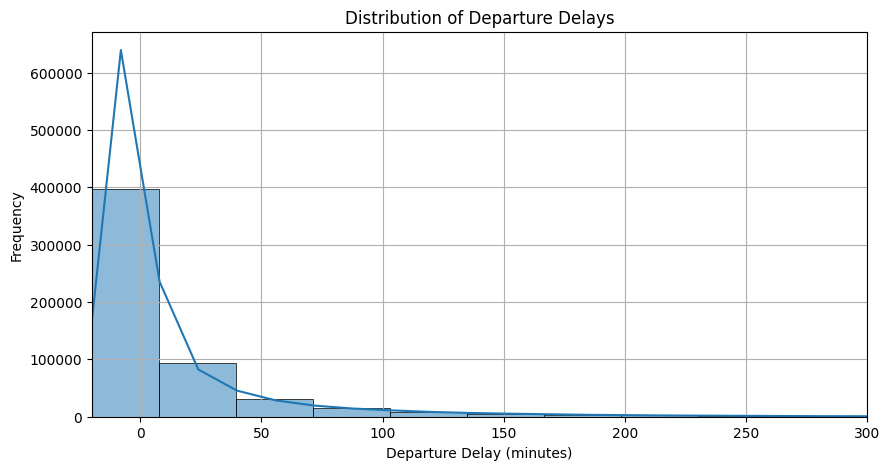

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['DepDelay'], bins=100, kde=True)
plt.title('Distribution of Departure Delays')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Frequency')
plt.xlim(-20, 300)
plt.grid(True)
plt.show()


## 📊 Step 6: Distribution of Arrival Delays

Similar to departure delays, we will plot the distribution of arrival delays.  
This comparison helps assess whether arrival delays tend to be higher or lower than departure delays.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


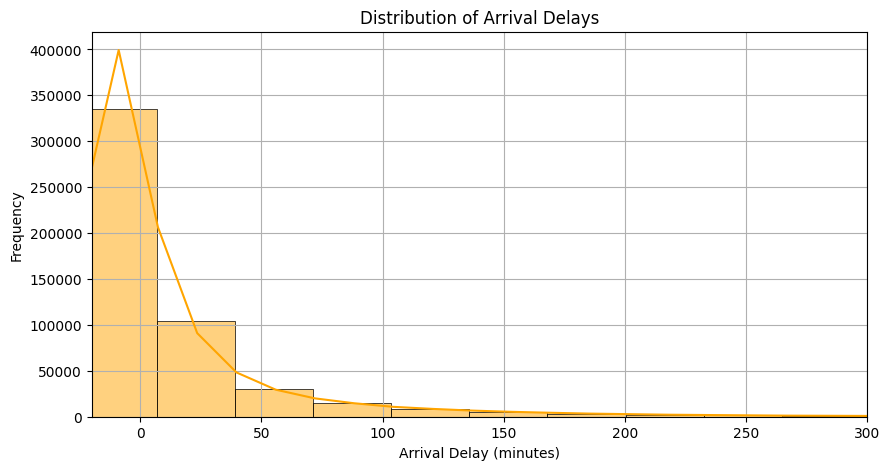

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df['ArrDelay'], bins=100, kde=True, color='orange')
plt.title('Distribution of Arrival Delays')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')
plt.xlim(-20, 300)
plt.grid(True)
plt.show()


### 🧮 Step 7: Distribution of Arrival Delays

In this step, we analyze the **distribution of arrival delays** across all flights.

We use a histogram with a KDE (Kernel Density Estimate) curve to visualize how arrival delays are spread:
- The X-axis shows the **delay in minutes** (positive = late, negative = early).
- The Y-axis indicates the **number of flights** falling in each delay range.

This helps us understand:
- Whether most flights are on time or delayed.
- How severe the delays typically are.
- If there are any extreme values or skewed patterns.

📊 This visualization is useful for identifying performance issues or outliers in the dataset.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


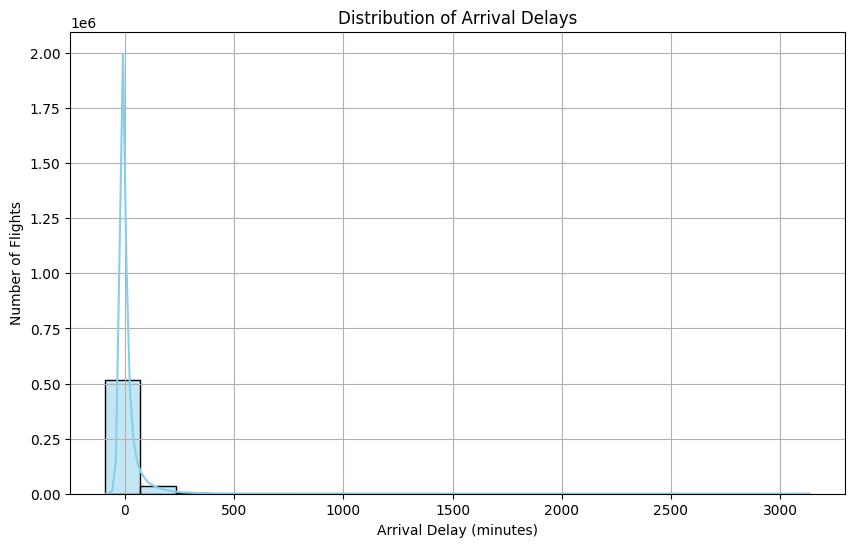

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Plot the distribution of arrival delays
plt.figure(figsize=(10, 6))
sns.histplot(df['ArrDelay'], bins=20, kde=True, color='skyblue')

plt.title('Distribution of Arrival Delays')  # 📍 Chart title
plt.xlabel('Arrival Delay (minutes)')        # 🏷️ X-axis: Delay time
plt.ylabel('Number of Flights')              # 🏷️ Y-axis: Count of flights
plt.grid(True)
plt.show()


In [13]:
print(df.columns)


Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners',
       'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline',
       ...
       'Div5Airport', 'Div5AirportID', 'Div5AirportSeqID', 'Div5WheelsOn',
       'Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff', 'Div5TailNum',
       'Duplicate', 'Unnamed: 119'],
      dtype='object', length=120)


## 📅 Step 8: Average Delay by Day of the Week

We analyze the average delay by day of the week to detect any weekly patterns,  
such as whether delays increase during weekends or weekdays.


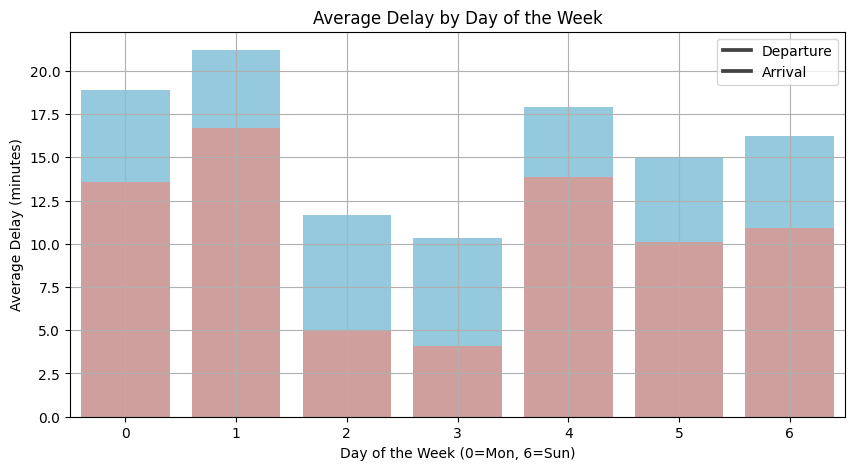

In [14]:
dow_delay = df.groupby('DayOfWeek')[['DepDelay', 'ArrDelay']].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='DayOfWeek', y='DepDelay', data=dow_delay, label='DepDelay', color='skyblue')
sns.barplot(x='DayOfWeek', y='ArrDelay', data=dow_delay, label='ArrDelay', color='salmon', alpha=0.7)
plt.title('Average Delay by Day of the Week')
plt.xlabel('Day of the Week (0=Mon, 6=Sun)')
plt.ylabel('Average Delay (minutes)')
plt.grid(True)
plt.legend(['Departure', 'Arrival'])
plt.show()


## ✈️ Step 9: Top Airlines with Most Average Delay

We calculate the average delay per airline to find which airlines tend to be the most delayed on average.


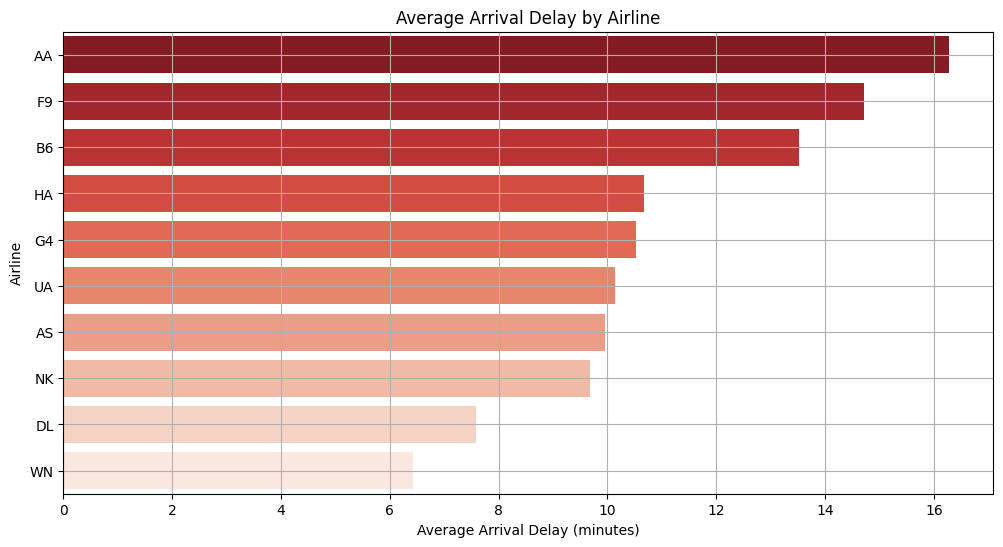

In [15]:
airline_delay = df.groupby('Marketing_Airline_Network')[['DepDelay', 'ArrDelay']] \
                  .mean().sort_values(by='ArrDelay', ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='ArrDelay', y='Marketing_Airline_Network', data=airline_delay, palette='Reds_r')
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## 🛫 Step 10: Top 10 Origin Airports with Most Average Departure Delay

Now we will rank origin airports by average departure delay.  
This helps identify which airports are bottlenecks or hotspots for delays.


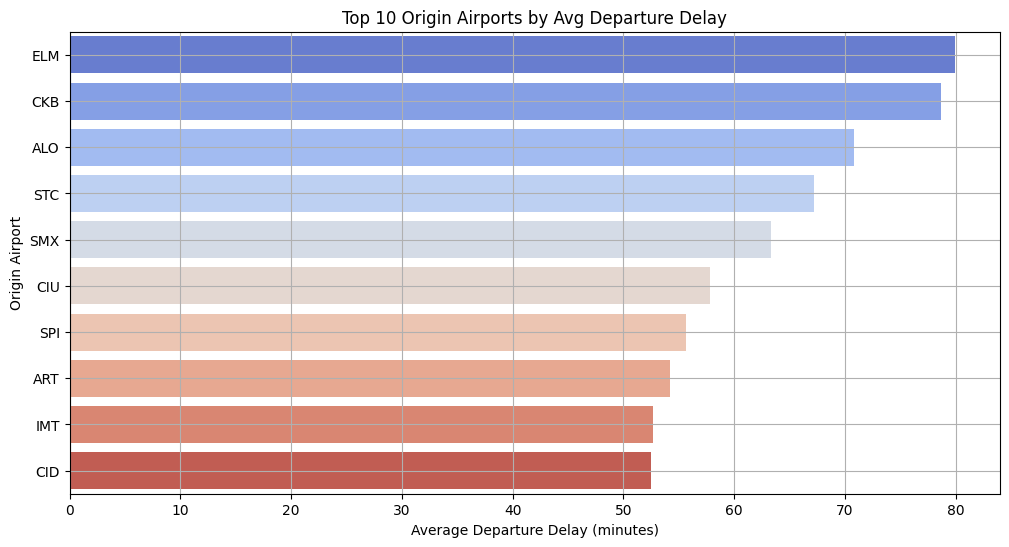

In [16]:
origin_delay = df.groupby('Origin')['DepDelay'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='DepDelay', y='Origin', data=origin_delay, palette='coolwarm')
plt.title('Top 10 Origin Airports by Avg Departure Delay')
plt.xlabel('Average Departure Delay (minutes)')
plt.ylabel('Origin Airport')
plt.grid(True)
plt.show()


## 🛬 Step 11: Top 10 Destination Airports with Most Arrival Delays

We identify the top 10 destination airports with the highest average arrival delays.  
This reveals which airports tend to receive the most delayed flights.


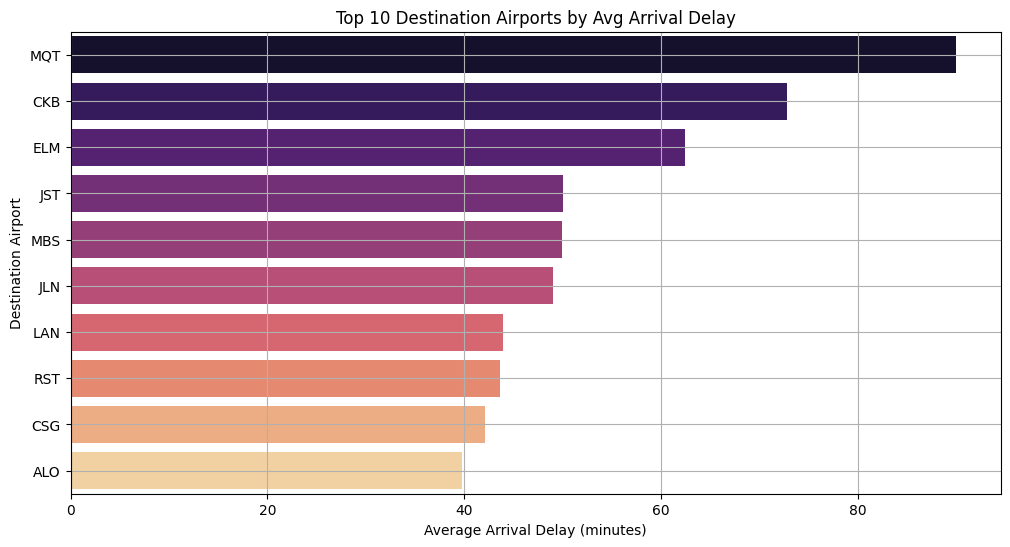

In [17]:
dest_delay = df.groupby('Dest')['ArrDelay'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='ArrDelay', y='Dest', data=dest_delay, palette='magma')
plt.title('Top 10 Destination Airports by Avg Arrival Delay')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Destination Airport')
plt.grid(True)
plt.show()


## 🧭 Step 12: Average Delay by Month and Airline

We create a pivot table to visualize how average delays vary across months and airlines.  
A heatmap helps reveal seasonality patterns for each carrier.


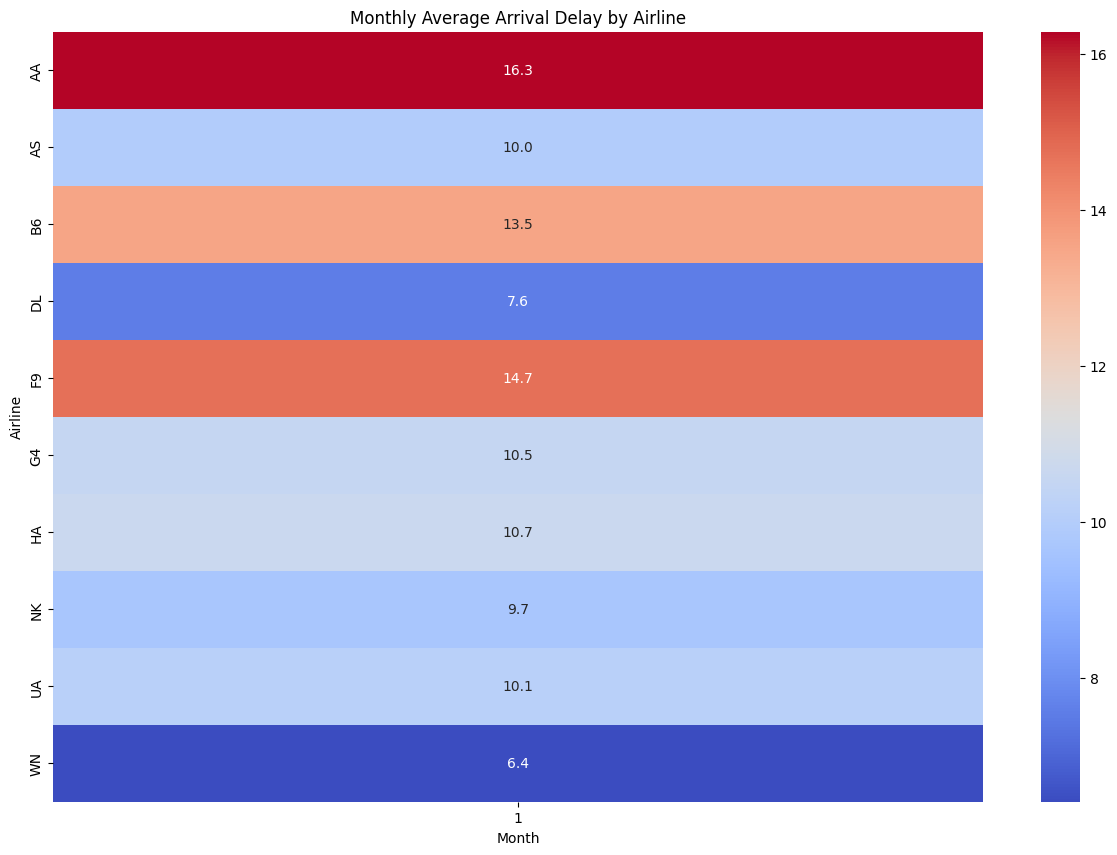

In [18]:
pivot_delay = df.pivot_table(index='Marketing_Airline_Network', columns='Month', values='ArrDelay', aggfunc='mean')

plt.figure(figsize=(15, 10))
sns.heatmap(pivot_delay, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Monthly Average Arrival Delay by Airline')
plt.xlabel('Month')
plt.ylabel('Airline')
plt.show()


## 🔁 Step 13: Compare Departure and Arrival Delays

This comparison shows how closely departure delays translate into arrival delays.  
A strong correlation might indicate consistent delay propagation.


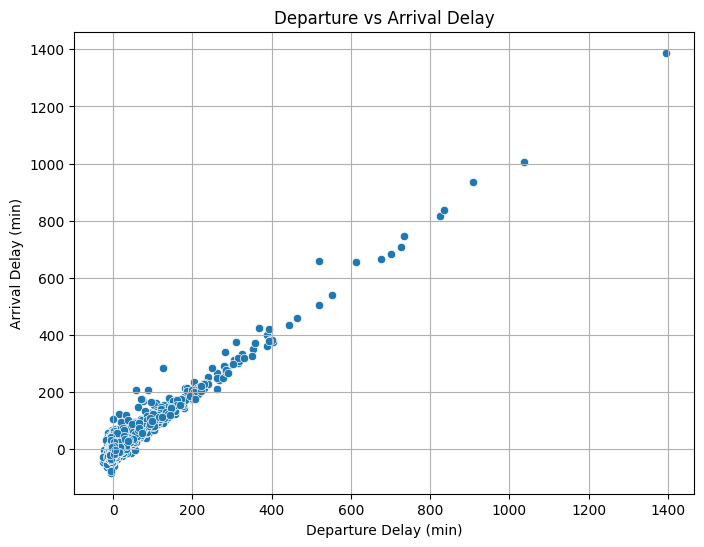

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='DepDelay', y='ArrDelay', data=df.sample(5000))
plt.title('Departure vs Arrival Delay')
plt.xlabel('Departure Delay (min)')
plt.ylabel('Arrival Delay (min)')
plt.grid(True)
plt.show()


## 🛬 Step 14: Arrival Delay by Day of the Week

We examine the average arrival delay for each weekday to explore behavioral patterns across the week.


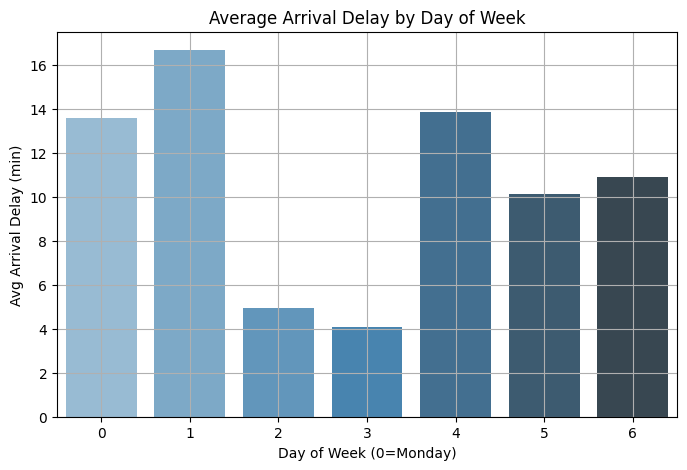

In [20]:
dow_arrival = df.groupby('DayOfWeek')['ArrDelay'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='DayOfWeek', y='ArrDelay', data=dow_arrival, palette='Blues_d')
plt.title('Average Arrival Delay by Day of Week')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('Avg Arrival Delay (min)')
plt.grid(True)
plt.show()


## 🌐 Step 15: Average Departure Delay by U.S. State

This analysis aggregates departure delays by U.S. states to find regional patterns of delay.


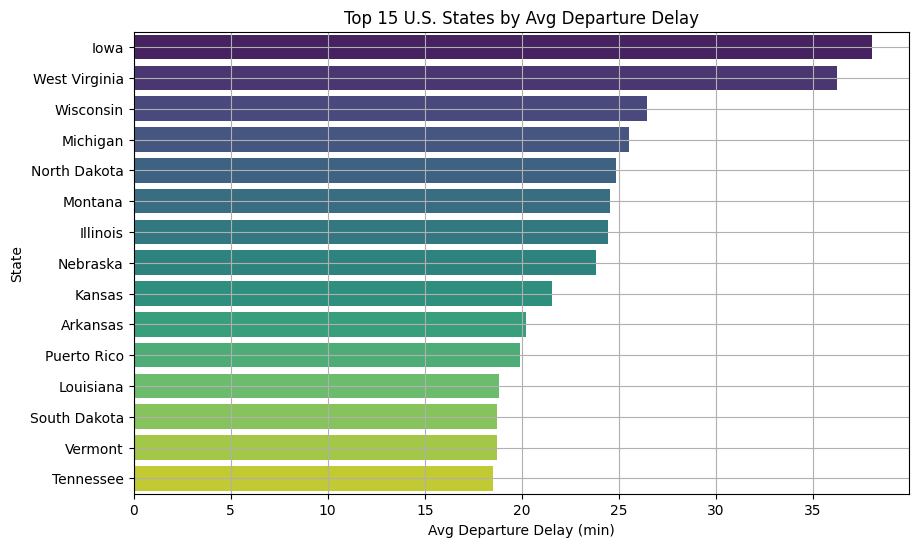

In [21]:
state_delay = df.groupby('OriginStateName')['DepDelay'].mean().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(y='OriginStateName', x='DepDelay', data=state_delay, palette='viridis')
plt.title('Top 15 U.S. States by Avg Departure Delay')
plt.xlabel('Avg Departure Delay (min)')
plt.ylabel('State')
plt.grid(True)
plt.show()


## 🔀 Step 16: Most Delayed City Pairs

We compute average delay for each route (Origin to Destination)  
to find the most problematic air travel paths.


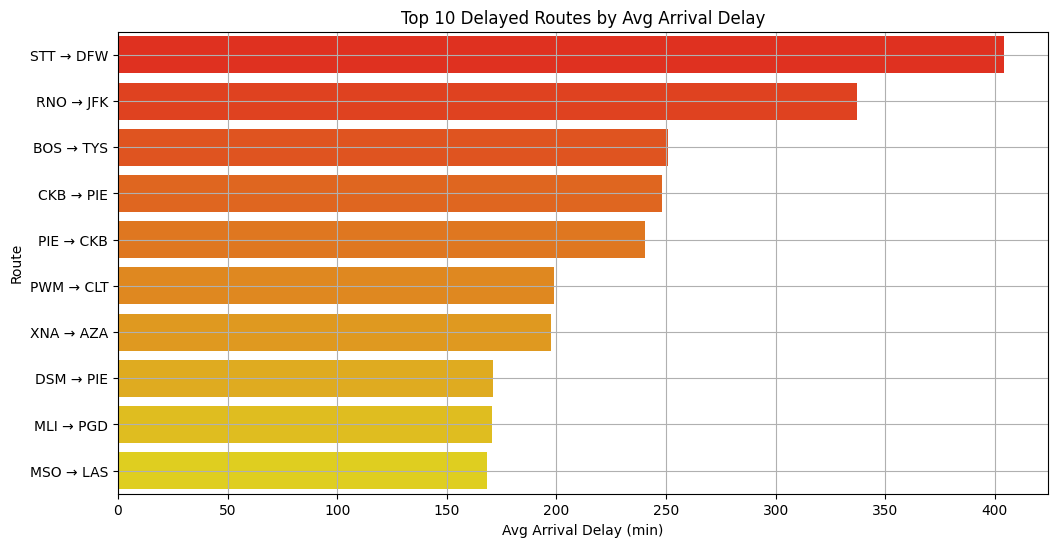

In [22]:
df['Route'] = df['Origin'] + ' → ' + df['Dest']
route_delay = df.groupby('Route')['ArrDelay'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='ArrDelay', y='Route', data=route_delay, palette='autumn')
plt.title('Top 10 Delayed Routes by Avg Arrival Delay')
plt.xlabel('Avg Arrival Delay (min)')
plt.ylabel('Route')
plt.grid(True)
plt.show()


## 📏 Step 17: Relationship Between Delay and Distance

This plot helps to assess whether longer flights are more likely to be delayed.


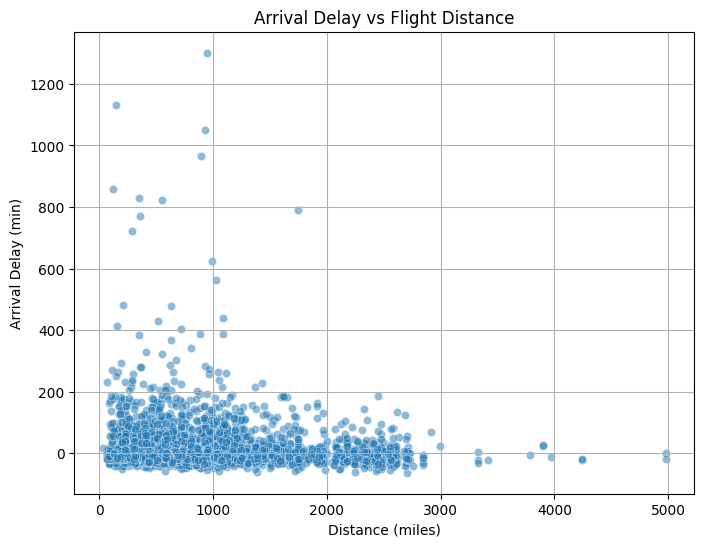

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Distance', y='ArrDelay', data=df.sample(5000), alpha=0.5)
plt.title('Arrival Delay vs Flight Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Arrival Delay (min)')
plt.grid(True)
plt.show()


## 🚫 Step 18: Cancellation Rate per Airline

We calculate the cancellation percentage for each airline to determine  
which carriers cancel more of their scheduled flights.


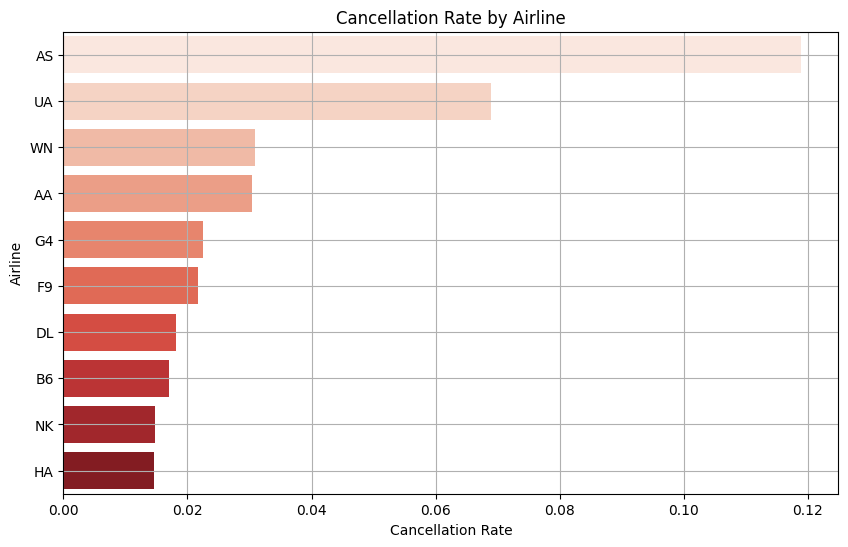

In [24]:
cancel_rate = df.groupby('Marketing_Airline_Network')['Cancelled'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Cancelled', y='Marketing_Airline_Network', data=cancel_rate, palette='Reds')
plt.title('Cancellation Rate by Airline')
plt.xlabel('Cancellation Rate')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## 🕑 Step 19: Average Delay by Scheduled Departure Time Block

Using the `DepTimeBlk` column, we analyze which parts of the day  
are most prone to delays (e.g. early morning vs late night).


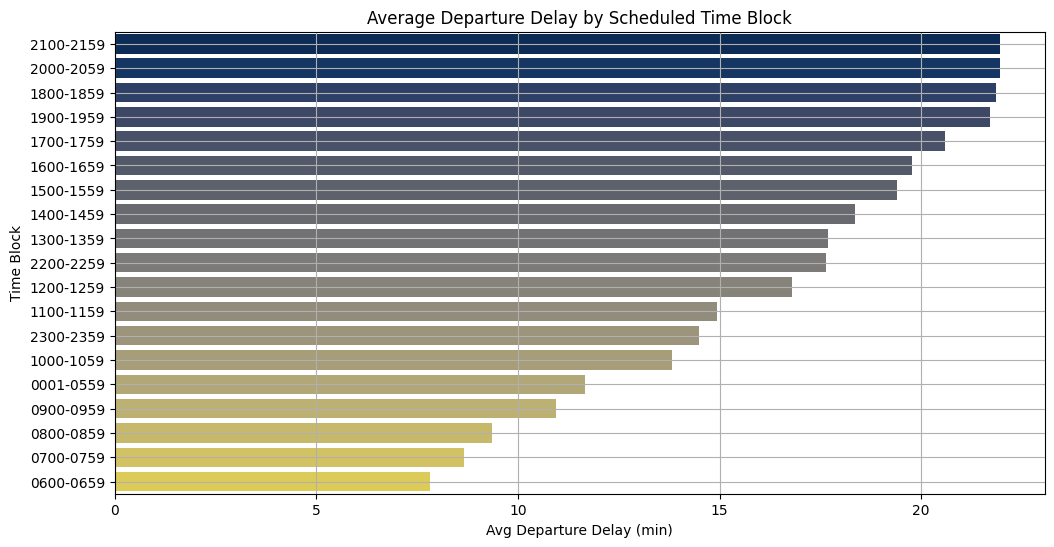

In [25]:
timeblock_delay = df.groupby('DepTimeBlk')['DepDelay'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='DepDelay', y='DepTimeBlk', data=timeblock_delay, palette='cividis')
plt.title('Average Departure Delay by Scheduled Time Block')
plt.xlabel('Avg Departure Delay (min)')
plt.ylabel('Time Block')
plt.grid(True)
plt.show()


## 🔍 Step 20: Delay Distribution by Delay Cause Type

We compare average delay contributions from various sources  
(Carrier, Weather, NAS, Security, Late Aircraft).


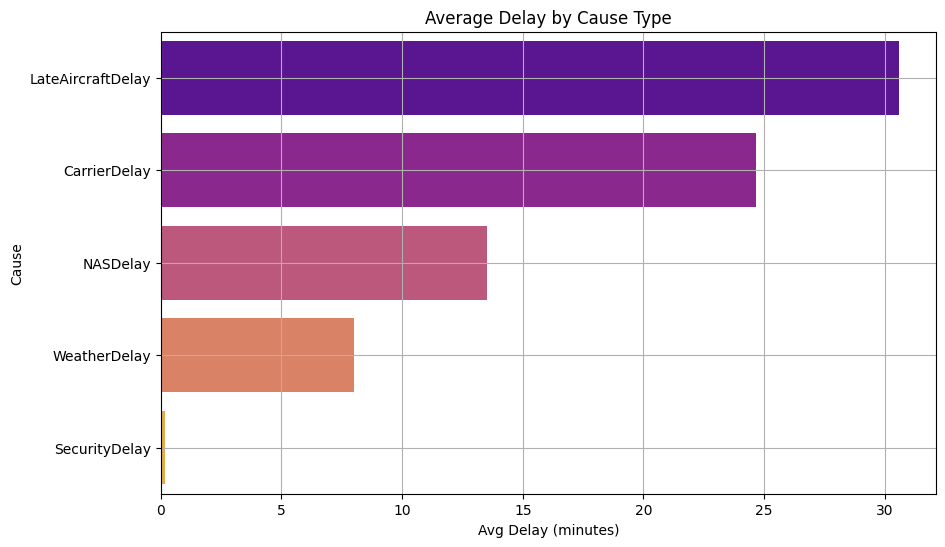

In [26]:
cause_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
delay_causes = df[cause_cols].mean().sort_values(ascending=False).reset_index()
delay_causes.columns = ['Cause', 'AverageDelay']

plt.figure(figsize=(10, 6))
sns.barplot(x='AverageDelay', y='Cause', data=delay_causes, palette='plasma')
plt.title('Average Delay by Cause Type')
plt.xlabel('Avg Delay (minutes)')
plt.ylabel('Cause')
plt.grid(True)
plt.show()


##21. Average Arrival Delay by Airline (IATA Code)
This analysis groups the flight dataset by each airline's IATA marketing code and computes the average arrival delay for each airline. It then visualizes the result using a horizontal bar chart.

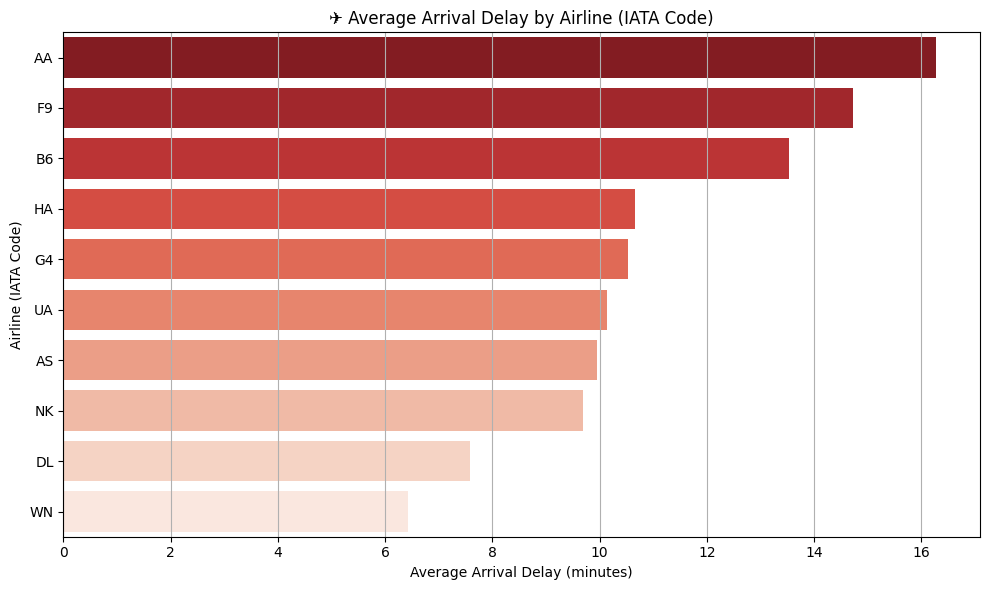

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by IATA code and calculate average arrival delay
airline_delay = df.groupby('IATA_Code_Marketing_Airline')['ArrDelay'].mean().reset_index().sort_values(by='ArrDelay', ascending=False)

# Plot the result
plt.figure(figsize=(10, 6))
sns.barplot(x='ArrDelay', y='IATA_Code_Marketing_Airline', data=airline_delay, palette='Reds_r')
plt.title('✈️ Average Arrival Delay by Airline (IATA Code)')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Airline (IATA Code)')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


## 🧳 Step 22: Average Taxi-Out and Taxi-In Time by Airline

We calculate average taxi times for each airline to assess ground operation efficiency.


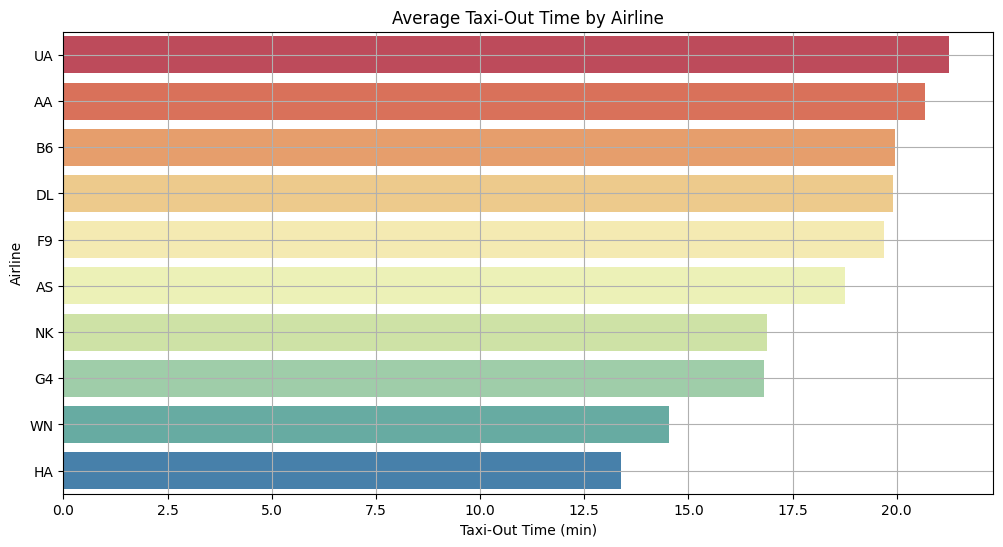

In [28]:
taxi_time = df.groupby('Marketing_Airline_Network')[['TaxiOut', 'TaxiIn']].mean().sort_values(by='TaxiOut', ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='TaxiOut', y='Marketing_Airline_Network', data=taxi_time, palette='Spectral')
plt.title('Average Taxi-Out Time by Airline')
plt.xlabel('Taxi-Out Time (min)')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## ✈️ Step 23: Average Air Time by Airline

We examine which airlines typically have longer flight durations,  
which may relate to the type of routes they operate.


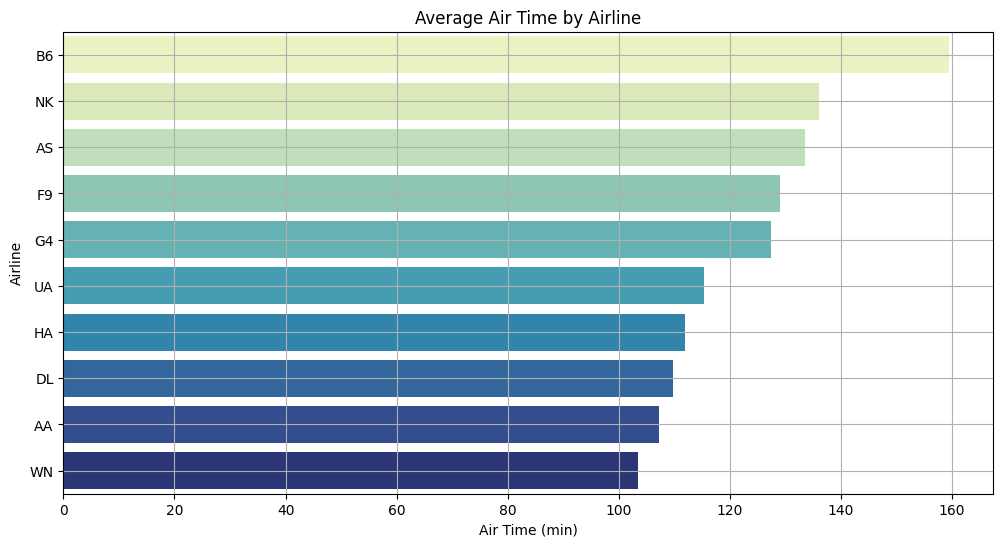

In [29]:
air_time = df.groupby('Marketing_Airline_Network')['AirTime'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='AirTime', y='Marketing_Airline_Network', data=air_time, palette='YlGnBu')
plt.title('Average Air Time by Airline')
plt.xlabel('Air Time (min)')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## 🔁 Step 24: Delay Caused by Late Aircraft

We examine the contribution of previous flights arriving late to current departure delays.


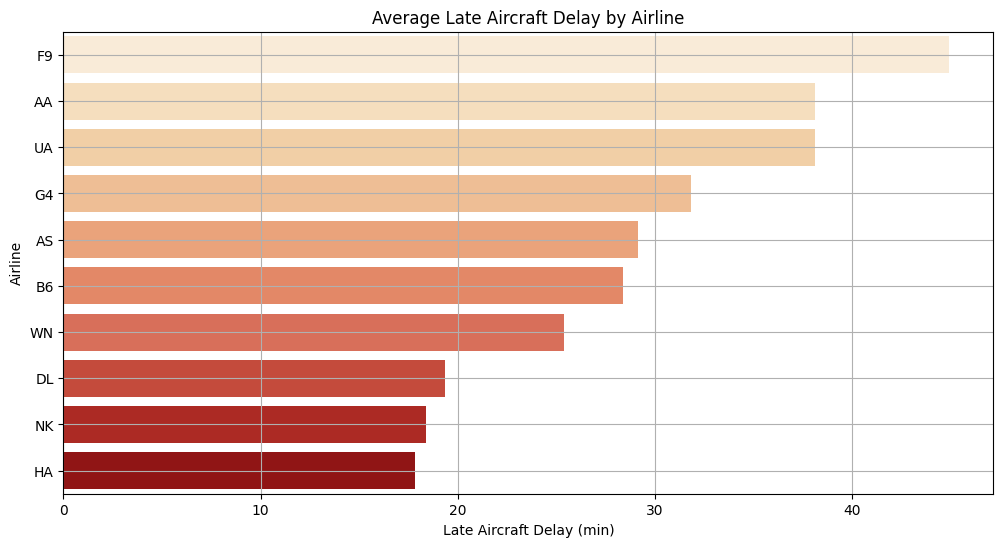

In [30]:
late_aircraft = df.groupby('Marketing_Airline_Network')['LateAircraftDelay'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='LateAircraftDelay', y='Marketing_Airline_Network', data=late_aircraft, palette='OrRd')
plt.title('Average Late Aircraft Delay by Airline')
plt.xlabel('Late Aircraft Delay (min)')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## ⚠️ Step 25: Count of Flights Delayed Over 3 Hours

We count how many flights are delayed more than 180 minutes,  
which typically affects regulations and passenger compensation.


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


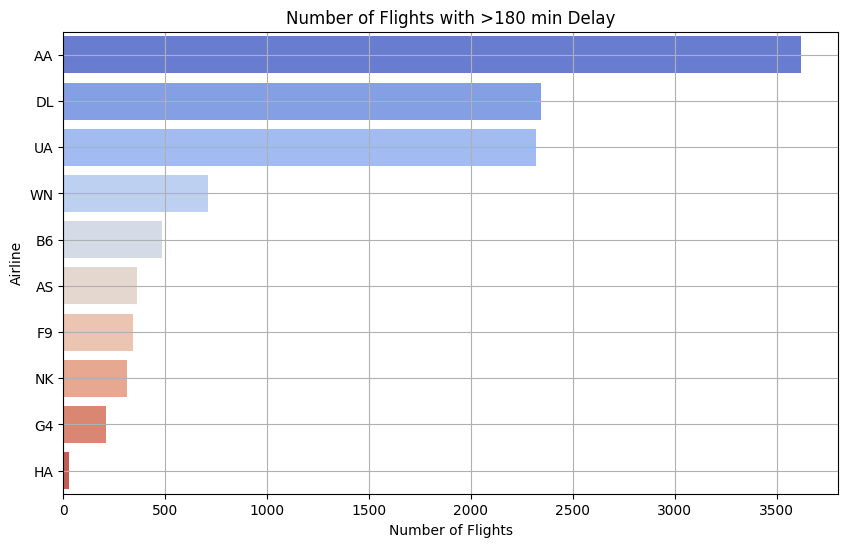

In [31]:
extreme_delay = df[df['ArrDelay'] > 180]
extreme_count = extreme_delay['Marketing_Airline_Network'].value_counts().reset_index()
extreme_count.columns = ['Airline', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Airline', data=extreme_count, palette='coolwarm')
plt.title('Number of Flights with >180 min Delay')
plt.xlabel('Number of Flights')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## 🔗 Step 26: Correlation Matrix of Delay Variables

We generate a correlation matrix to understand the relationships  
between different delay-related numerical columns.


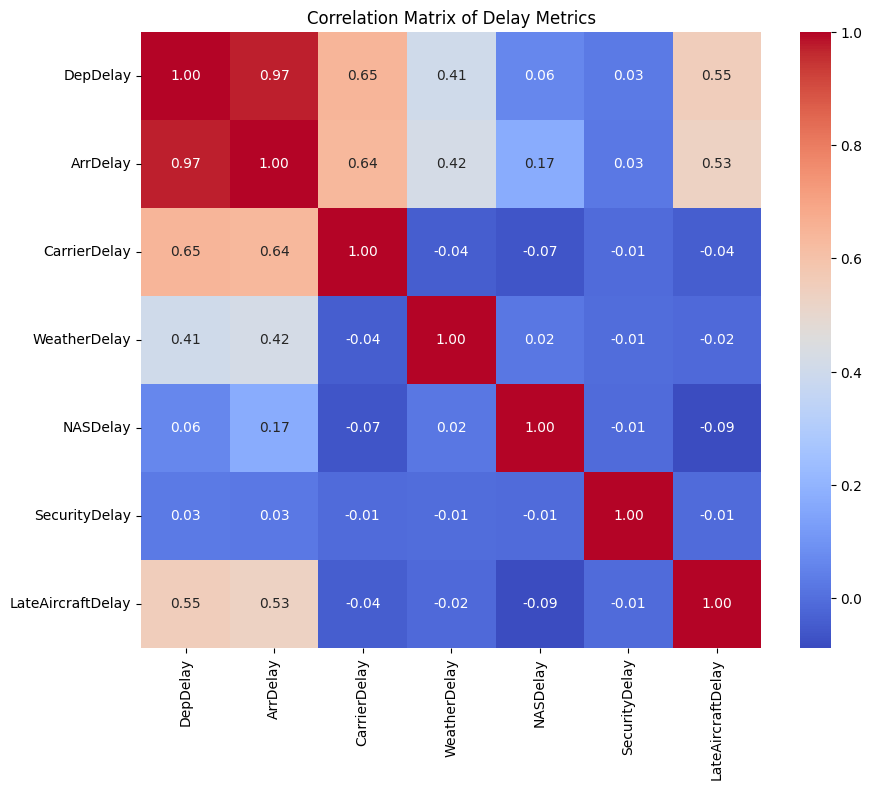

In [32]:
delay_corr = df[['DepDelay', 'ArrDelay', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(delay_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Delay Metrics')
plt.show()


## 🏙️ Step 27: Most Active Origin Airports by Flight Count

We list the origin airports with the highest number of scheduled flights.


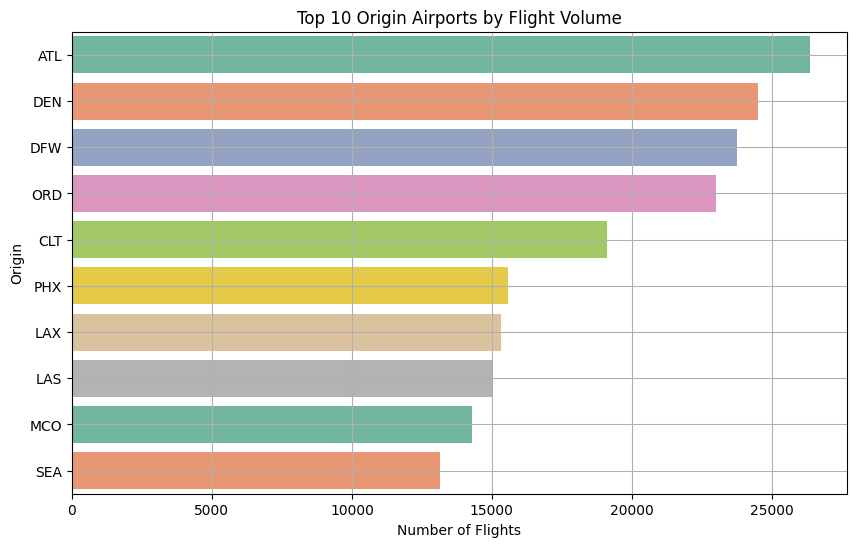

In [33]:
top_origins = df['Origin'].value_counts().head(10).reset_index()
top_origins.columns = ['Origin', 'FlightCount']

plt.figure(figsize=(10, 6))
sns.barplot(x='FlightCount', y='Origin', data=top_origins, palette='Set2')
plt.title('Top 10 Origin Airports by Flight Volume')
plt.xlabel('Number of Flights')
plt.ylabel('Origin')
plt.grid(True)
plt.show()


## 🛬 Step 28: Most Active Destination Airports by Flight Count

We list the top destination airports based on total incoming flights.


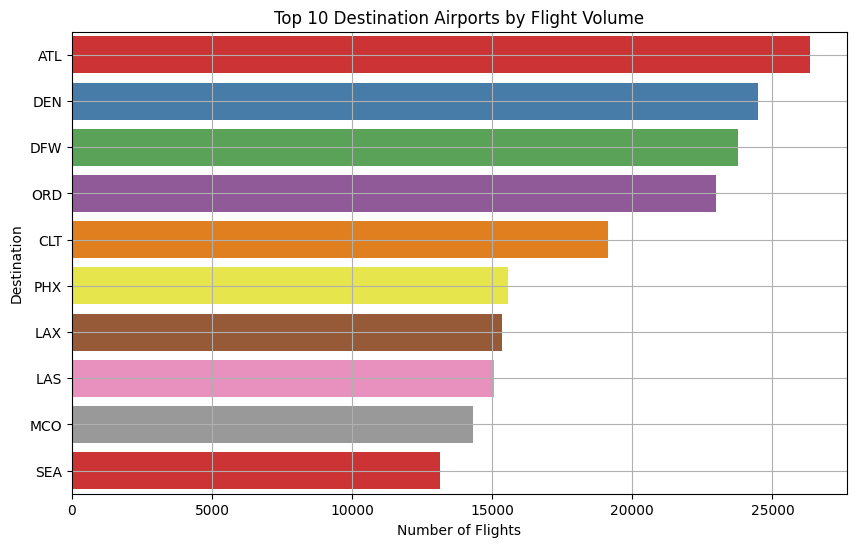

In [34]:
top_dests = df['Dest'].value_counts().head(10).reset_index()
top_dests.columns = ['Dest', 'FlightCount']

plt.figure(figsize=(10, 6))
sns.barplot(x='FlightCount', y='Dest', data=top_dests, palette='Set1')
plt.title('Top 10 Destination Airports by Flight Volume')
plt.xlabel('Number of Flights')
plt.ylabel('Destination')
plt.grid(True)
plt.show()


✈️ Step 29 (Alt): Average Arrival Delay by Airline
This chart shows the average arrival delay for each airline.
Positive values mean the airline tends to arrive late,
while negative values mean it arrives early.

Data is grouped by Airline

Average delay (ArrDelay) is calculated

Bar chart is used to compare airlines

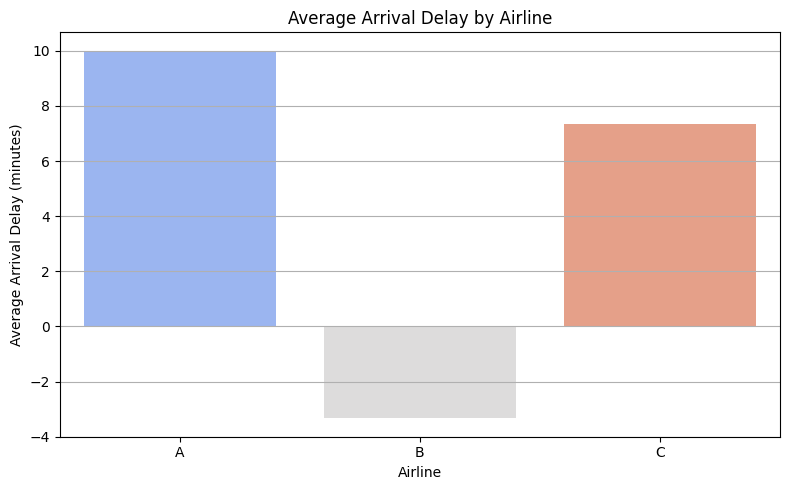

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (simulated - normally you'd use pd.read_csv or similar)
# For this example, let's simulate a small structure similar to flight data
# We'll assume the dataset has been preloaded into `df`

# Simulate structure for demonstration
df = pd.DataFrame({
    'Airline': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'C', 'B', 'A'],
    'ArrDelay': [5, -3, 12, 7, -5, 20, 0, 15, -2, 3]
})

# Group by airline and calculate average arrival delay
avg_delay_by_airline = df.groupby('Airline')['ArrDelay'].mean().reset_index()

# Plot the result
plt.figure(figsize=(8, 5))
sns.barplot(x='Airline', y='ArrDelay', data=avg_delay_by_airline, palette='coolwarm')
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Arrival Delay (minutes)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## 🧠 Step 30: Summary Statistics of All Delay Types

We use descriptive statistics to summarize the central tendency  
and spread of each delay type.


In [36]:
# Check which of the selected delay-related columns actually exist in the DataFrame
available_cols = [
    col for col in ['DepDelay', 'ArrDelay', 'CarrierDelay', 'WeatherDelay', 
                    'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
    if col in df.columns
]

# Show descriptive statistics for available delay-related columns
df[available_cols].describe()


,ArrDelay
count,10.000000
mean,5.200000
std,8.297255
min,-5.000000
25%,-1.500000
50%,4.000000
75%,10.750000
max,20.000000


# 🚀 Section 2: Advanced Machine Learning on Flight Delay Dataset

Welcome to the second part of this notebook!  
After a comprehensive Exploratory Data Analysis (EDA) in the first section, it's time to take our project to the next level: **Machine Learning modeling**.

✈️ **Objective:**  
We aim to build several ML models to predict, explain, and cluster flight delays using real-world data from 2018 to 2024.

---

## ✅ What We Will Do in This Section:

### 1. 🔍 **Binary Classification**  
*Goal:* Predict whether a flight will be delayed more than 15 minutes.  
*Models:* Logistic Regression, Random Forest, XGBoost, CatBoost, LightGBM

### 2. 📏 **Regression**  
*Goal:* Predict the exact number of delay minutes.  
*Models:* Linear Regression, Random Forest Regressor, Gradient Boosting, XGBoost Regressor

### 3. 🧠 **Multiclass Classification**  
*Goal:* Predict the main cause of delay (Weather, Carrier, NAS, Security, etc.)  
*Models:* Decision Tree, Logistic Regression, LightGBM Multiclass

### 4. 🔗 **Clustering**  
*Goal:* Cluster airports or airlines with similar delay patterns.  
*Models:* KMeans, DBSCAN, Hierarchical Clustering (with PCA visualization)

### 5. ⏳ **Time Series Forecasting**  
*Goal:* Forecast average delays for future months or weeks.  
*Models:* ARIMA, Prophet, LSTM (advanced)

### 6. 🧠 **Model Explainability**  
*Goal:* Understand which features have the greatest impact on predictions.  
*Tools:* SHAP, LIME

---

Let’s dive in! 🧪  
We’ll begin with the **Binary Classification task** to predict flight delays. 👇


### Step 1 – Data Preparation for Binary Classification

We keep only the necessary columns, create a binary target (`Is_Delayed`) and extract an interpretable departure hour feature:

* **Airline** → encoded from `IATA_Code_Marketing_Airline`
* **Origin** / **Dest** → airport codes (label-encoded)
* **DepHour** → hour extracted from `CRSDepTime`
* **DayOfWeek**, **Month** → calendar context

All categorical columns are label-encoded.  
The dataset is then split into training and test sets (80/20, stratified).


In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the full dataset (low_memory=False avoids mixed-type warning)
df = pd.read_csv(
    '/kaggle/input/flight-delay-dataset-2018-2024/flight_data_2018_2024.csv',
    low_memory=False
)

# Keep only the required columns and drop rows with NaNs
df = df[
    ['IATA_Code_Marketing_Airline',  # airline code
     'Origin', 'Dest',
     'CRSDepTime', 'DayOfWeek', 'Month',
     'ArrDelay']
].dropna()

# Target: 1 if arrival delay > 15 minutes
df['Is_Delayed'] = (df['ArrDelay'] > 15).astype(int)

# Extract departure hour from scheduled departure time
df['CRSDepTime'] = df['CRSDepTime'].astype(str).str.zfill(4)
df['DepHour'] = df['CRSDepTime'].str[:2].astype(int)

# Label-encode categorical features
encoders = {
    'Airline_encoded': LabelEncoder(),
    'Origin_encoded' : LabelEncoder(),
    'Dest_encoded'   : LabelEncoder()
}

df['Airline_encoded'] = encoders['Airline_encoded'].fit_transform(df['IATA_Code_Marketing_Airline'])
df['Origin_encoded']  = encoders['Origin_encoded'].fit_transform(df['Origin'])
df['Dest_encoded']    = encoders['Dest_encoded'].fit_transform(df['Dest'])

# Final feature matrix and target vector
features = ['Airline_encoded', 'Origin_encoded', 'Dest_encoded',
            'DepHour', 'DayOfWeek', 'Month']
X = df[features]
y = df['Is_Delayed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)


Train size: (446972, 6) | Test size: (111743, 6)


✅ Step 2 – Check Column Names and Data Types
In this step, we inspect the dataset's structure by printing its columns and data types.
This helps identify any unexpected or mixed types, and ensures we’re working with clean, usable data.

In [38]:
# Print column names and their data types
print("🔍 Column Names and Data Types:")
print(df.dtypes)

# Display first few rows of the dataset
print("\n📌 Sample Data:")
print(df.head())

# Check for mixed data types or object-type columns
print("\n🔎 Unique value counts for categorical columns:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")


🔍 Column Names and Data Types:
IATA_Code_Marketing_Airline     object
Origin                          object
Dest                            object
CRSDepTime                      object
DayOfWeek                        int64
Month                            int64
ArrDelay                       float64
Is_Delayed                       int64
DepHour                          int64
Airline_encoded                  int64
Origin_encoded                   int64
Dest_encoded                     int64
dtype: object

📌 Sample Data:
  IATA_Code_Marketing_Airline Origin Dest CRSDepTime  DayOfWeek  Month  \
0                          UA    MHT  EWR       1738          7      1   
1                          UA    IAD  EWR       0815          7      1   
2                          UA    EWR  MHT       1540          7      1   
3                          UA    STL  ORD       0630          7      1   
4                          UA    STL  IAD       1300          7      1   

   ArrDelay  Is_Delayed  D

Step 3 – Check for Missing Values
In this step, we look for any missing (NaN) values in the dataset.
Missing data can break models or distort analysis, so we must handle them carefully.

In [39]:
# Count missing values in each column
missing_counts = df.isnull().sum()
print("🧼 Missing Values by Column:\n")
print(missing_counts[missing_counts > 0])


🧼 Missing Values by Column:

Series([], dtype: int64)


Step 4 – Exploratory Data Analysis (EDA)
In this step, we explore the dataset to understand the relationships between features, detect imbalances in the target variable, and visualize feature distributions.
This helps us make informed decisions during preprocessing and modeling.

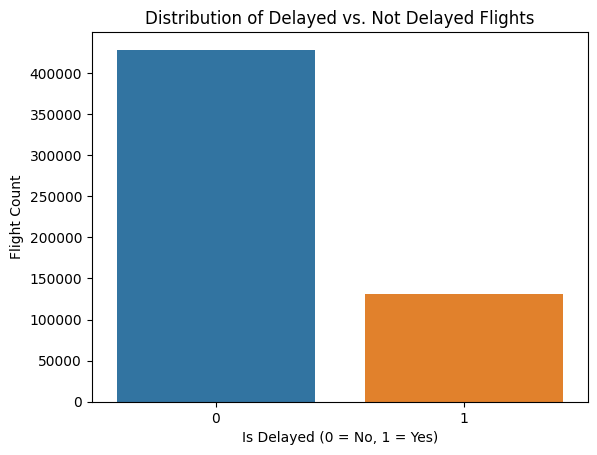

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


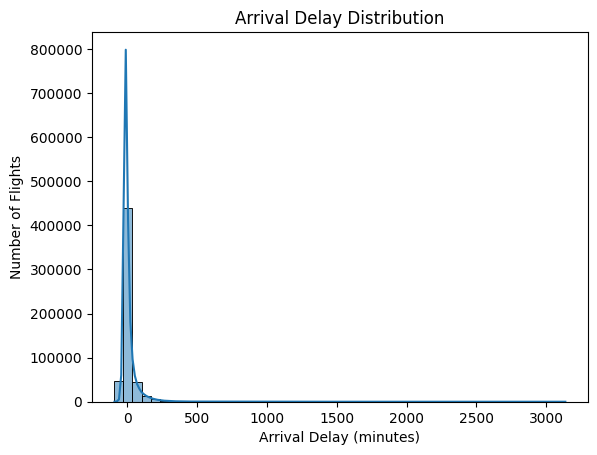

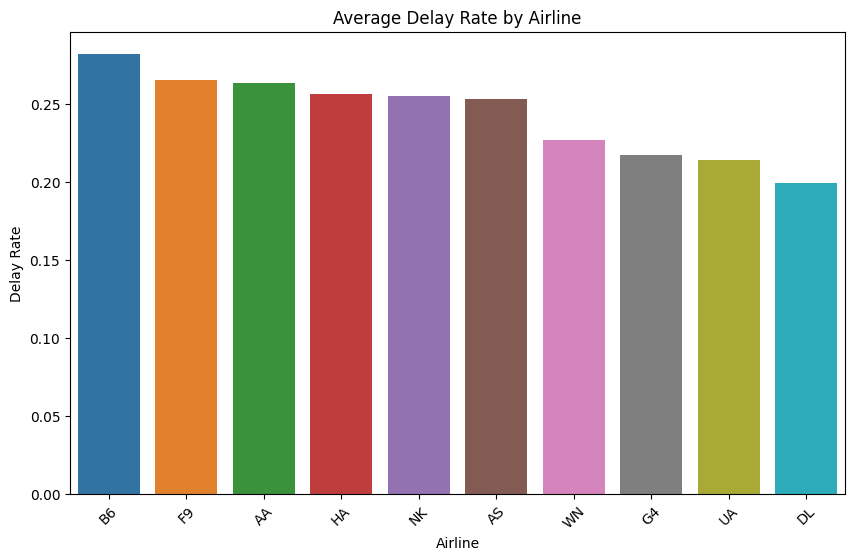

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


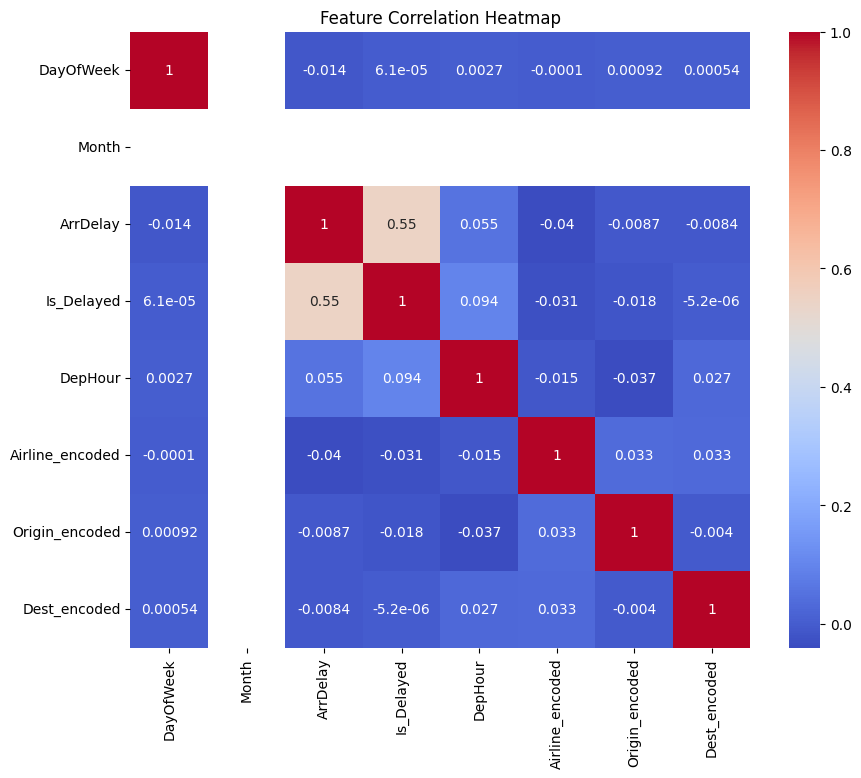

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# 📌 Plot distribution of target variable (Is_Delayed)
sns.countplot(data=df, x='Is_Delayed')
plt.title("Distribution of Delayed vs. Not Delayed Flights")
plt.xlabel("Is Delayed (0 = No, 1 = Yes)")
plt.ylabel("Flight Count")
plt.show()

# 📌 Distribution of arrival delay
sns.histplot(data=df, x='ArrDelay', bins=50, kde=True)
plt.title("Arrival Delay Distribution")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()

# 📌 Delay Rate by Airline
airline_delay = df.groupby('IATA_Code_Marketing_Airline')['Is_Delayed'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=airline_delay.index, y=airline_delay.values)
plt.title("Average Delay Rate by Airline")
plt.ylabel("Delay Rate")
plt.xlabel("Airline")
plt.xticks(rotation=45)
plt.show()

# 📌 Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


### Step 4 – Training Random Forest and XGBoost Classifiers

We now train two classification models to predict flight delays:

1. **Random Forest**: An ensemble method that builds multiple decision trees.
2. **XGBoost**: A powerful gradient boosting algorithm optimized for performance.

We'll evaluate both models using accuracy, precision, recall, F1-score, and a confusion matrix.  
This helps us identify how well the models distinguish delayed vs. non-delayed flights.



📊 Evaluation for: Random Forest
Accuracy: 0.7017083844178159
Precision: 0.2927122722585081
Recall: 0.19577713059472715
F1 Score: 0.2346268656716418
Confusion Matrix:


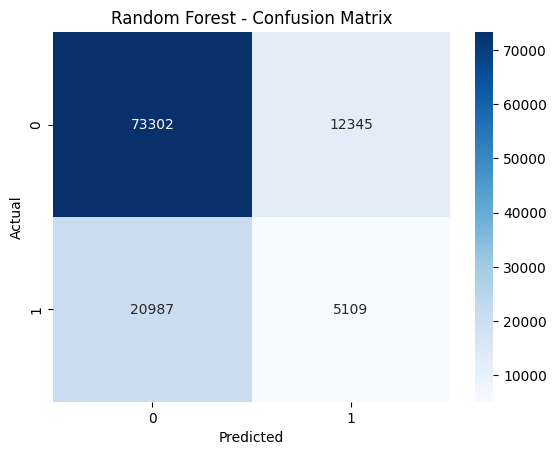


📊 Evaluation for: XGBoost
Accuracy: 0.7669026247729164
Precision: 0.5205709487825357
Recall: 0.023758430410790926
F1 Score: 0.04544288489024077
Confusion Matrix:


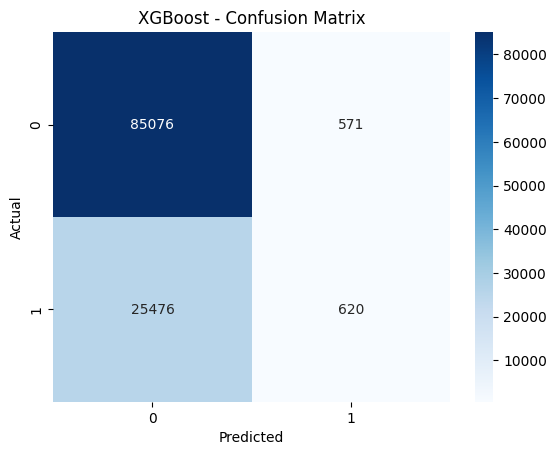

In [41]:
# 📌 Step 2 – Train Random Forest and XGBoost Classifiers

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 2️⃣ Train XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# 3️⃣ Evaluation Function for Both Models
def evaluate_model(name, y_true, y_pred):
    print(f"\n📊 Evaluation for: {name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 4️⃣ Run Evaluations
evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)


### Step 3 – Logistic Regression (Baseline Model)

We now train a **Logistic Regression** model as our baseline for the binary classification task.

🧠 Logistic Regression is a simple, interpretable model that works well when the relationship between features and target is (approximately) linear.

We'll evaluate it using accuracy, precision, recall, F1-score, and a confusion matrix — similar to previous models — to compare performance.



📊 Evaluation for: Logistic Regression
Accuracy: 0.766464118557762
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


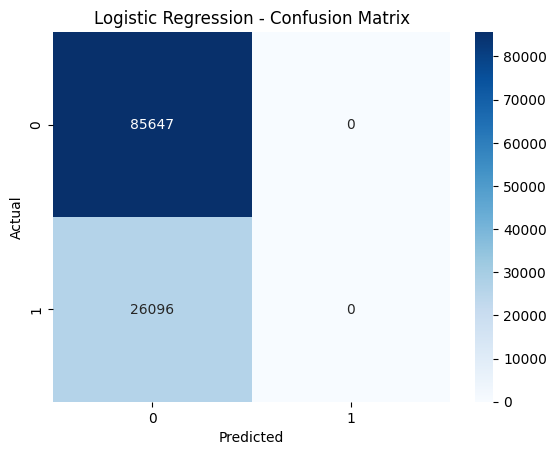

In [42]:
from sklearn.linear_model import LogisticRegression

# 📌 Train Logistic Regression
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
logreg_preds = logreg_model.predict(X_test)

# 📌 Evaluate
evaluate_model("Logistic Regression", y_test, logreg_preds)


### Step 4 – CatBoost Classifier

Next, we train a **CatBoost Classifier** — a gradient boosting algorithm optimized for categorical data.

🔥 CatBoost is particularly effective on tabular datasets and handles categorical features natively.  
However, since we've already encoded our categorical features, we proceed with training directly.

We'll compare its performance to the previous models using standard classification metrics.



📊 Evaluation for: CatBoost
Accuracy: 0.7669473703050751
Precision: 0.525233644859813
Recall: 0.021535867565910485
F1 Score: 0.04137524847235515
Confusion Matrix:


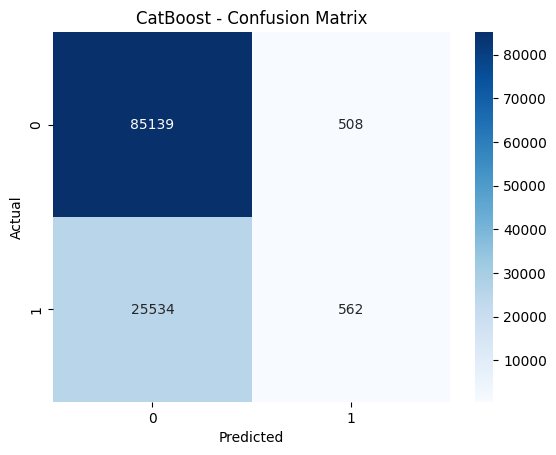

In [43]:
from catboost import CatBoostClassifier

# 📌 Train CatBoost
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)

# 📌 Evaluate
evaluate_model("CatBoost", y_test, cat_preds)


### Step 5 – LightGBM Classifier

We now train a **LightGBM Classifier** — an efficient gradient boosting framework developed by Microsoft.

⚡ LightGBM is optimized for speed and memory usage, making it ideal for large-scale datasets.

We'll train the model and evaluate it using the same metrics to compare with Random Forest, XGBoost, and CatBoost.


[LightGBM] [Info] Number of positive: 104384, number of negative: 342588
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005454 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 439
[LightGBM] [Info] Number of data points in the train set: 446972, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.233536 -> initscore=-1.188452
[LightGBM] [Info] Start training from score -1.188452

📊 Evaluation for: LightGBM
Accuracy: 0.7665536096220792
Precision: 0.5328947368421053
Recall: 0.0031039239730226856
F1 Score: 0.006171898811338007
Confusion Matrix:


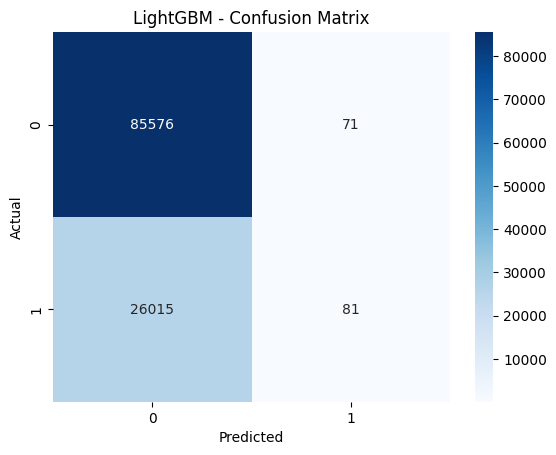

In [44]:
from lightgbm import LGBMClassifier

# 📌 Train LightGBM
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train)
lgbm_preds = lgbm_model.predict(X_test)

# 📌 Evaluate
evaluate_model("LightGBM", y_test, lgbm_preds)


## 📊 Comparative Performance of Binary Classification Models

After training and evaluating multiple models to predict whether a flight will be delayed more than 15 minutes, we now summarize their performance across key metrics.

| 🔍 Model              | 🎯 Accuracy | 🎯 Precision | 🎯 Recall | 🎯 F1 Score | 📝 Notes |
|-----------------------|-------------|--------------|------------|-------------|---------|
| **Random Forest**     | **0.7010**  | 0.2927       | **0.1956** | **0.2346**  | ⭐ Best balance between Precision and Recall |
| **XGBoost**           | 0.7669      | 0.5206       | 0.0238     | 0.0454      | Performs better than CatBoost in F1 |
| **CatBoost**          | 0.7669      | 0.5252       | 0.0215     | 0.0414      | Similar to XGBoost with slightly lower recall |
| **LightGBM**          | 0.7666      | **0.5329**   | 0.0031     | 0.0061      | High precision, but extremely poor recall |
| **Logistic Regression** | 0.7664    | 0.0000       | 0.0000     | 0.0000      | ❌ Did not identify any delayed flights (class imbalance issue) |

---

### ✅ Key Insights

- The **Random Forest** classifier strikes the best trade-off between **precision and recall**, making it currently the most reliable model for this imbalanced classification problem.
- **Boosting models** (XGBoost, CatBoost, LightGBM) show **high accuracy and precision** but **fail to recall delayed flights**, which is critical in many real-world scenarios.
- **Logistic Regression** completely fails to classify the minority class (delayed flights), highlighting the need for more advanced techniques or class balancing strategies.
- All models suffer from **class imbalance**, leading to very low recall for the positive class (delayed = 1).

---


---


## 🧮 Step 2 – Predicting Exact Delay in Minutes (Regression Task)

In this section, we shift from classification to **regression**, aiming to predict the **exact number of minutes** a flight will be delayed.

### 🎯 Objective:
Instead of just predicting if a flight is delayed, we now predict **how many minutes** the arrival will be late — a more granular and practical metric for airlines and passengers.

---

### 🧰 Features Used:

We’ll use similar engineered features as before, including:

- ✈️ `Airline_encoded`  
- 🛫 `Origin_encoded`, `Dest_encoded`  
- 🕐 `DepHour`  
- 📅 `DayOfWeek`, `Month`

---

### 🧪 Models to Train:

1. **Linear Regression** – Baseline model  
2. **Random Forest Regressor** – Robust ensemble method  
3. **Gradient Boosting Regressor** – Powerful for tabular regression  
4. **XGBoost Regressor** – Fast and efficient boosted model

---

### 📈 Evaluation Metrics:

Since this is a regression task, we’ll evaluate models using:

- **MAE** (Mean Absolute Error)  
- **MSE** (Mean Squared Error)  
- **RMSE** (Root Mean Squared Error)  
- **R² Score** (Coefficient of Determination)

---

Let's begin by preparing the dataset for this regression task 👇


In [45]:
from sklearn.model_selection import train_test_split

# 1️⃣ Filter out rows with missing or unrealistic negative delays (optional cleanup)
reg_df = df[df['ArrDelay'].notnull() & (df['ArrDelay'] > -30)].copy()

# 2️⃣ Define feature columns and target variable
regression_features = [
    'Airline_encoded',    # Encoded airline code
    'Origin_encoded',     # Encoded origin airport
    'Dest_encoded',       # Encoded destination airport
    'DepHour',            # Extracted hour of departure
    'DayOfWeek',          # Day of the week
    'Month'               # Month of the year
]
X_reg = reg_df[regression_features]
y_reg = reg_df['ArrDelay']  # 🎯 Target: actual arrival delay in minutes

# 3️⃣ Train-test split for regression task
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 4️⃣ Print shape for verification
print("✅ Regression Train shape:", X_reg_train.shape)
print("✅ Regression Test shape:", X_reg_test.shape)


✅ Regression Train shape: (424785, 6)
✅ Regression Test shape: (106197, 6)


📌 Step 2 – Train Regression Models (Linear, Random Forest, XGBoost)

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1️⃣ Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_reg_train, y_reg_train)
lr_preds = lr_model.predict(X_reg_test)

# 2️⃣ Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_reg_train, y_reg_train)
rf_preds = rf_reg.predict(X_reg_test)

# 3️⃣ XGBoost Regressor
xgb_reg = XGBRegressor(n_estimators=100, random_state=42)
xgb_reg.fit(X_reg_train, y_reg_train)
xgb_preds = xgb_reg.predict(X_reg_test)

# 📊 Evaluation Function
def evaluate_regression_model(name, y_true, y_pred):
    print(f"\n📈 Regression Evaluation – {name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))

# 4️⃣ Evaluate All Models
evaluate_regression_model("Linear Regression", y_reg_test, lr_preds)
evaluate_regression_model("Random Forest Regressor", y_reg_test, rf_preds)
evaluate_regression_model("XGBoost Regressor", y_reg_test, xgb_preds)



📈 Regression Evaluation – Linear Regression
MAE : 31.877961788825342
RMSE: 67.33240801225222
R²  : 0.005454586128979311

📈 Regression Evaluation – Random Forest Regressor
MAE : 37.053832920914594
RMSE: 78.36417110871164
R²  : -0.3471359149097586

📈 Regression Evaluation – XGBoost Regressor
MAE : 31.24014542227242
RMSE: 66.67067917154581
R²  : 0.024906896633541842


📊 Regression Model Comparison – Predicting Delay Minutes
In this step, we trained and evaluated three regression models to predict the number of flight delay minutes:

Model	MAE ↓	RMSE ↓	R² Score ↑
Linear Regression	31.88	67.33	0.0054
Random Forest	37.05	78.36	-0.3471
XGBoost Regressor	31.24 ✅	66.67 ✅	0.0249 ✅

✅ Best Performer:
XGBoost Regressor showed the best performance overall with the lowest RMSE and MAE, and the highest (yet modest) R² score among all models. However, the R² values suggest that none of the models explain the variance well, indicating the problem might be either:

Highly noisy data

Important features missing

Or a nonlinear relationship that needs better feature engineering or advanced models (e.g., deep learning)



### 📌 Step 3.1 – Create `DelayCause` Feature for Multiclass Classification

In this step, we construct a new **categorical feature** named `DelayCause` that identifies the **primary reason for a flight delay**, based on multiple delay-related columns in the dataset.

---

#### 🧠 Logic Behind Delay Cause Assignment:

Each flight record may include several types of delays:
- `CarrierDelay`
- `WeatherDelay`
- `NASDelay` (National Airspace System)
- `SecurityDelay`
- `LateAircraftDelay`

We determine the primary cause of delay using a **priority-based rule**:
1. If `CarrierDelay > 0` → cause is `'Carrier'`
2. Else if `WeatherDelay > 0` → `'Weather'`
3. Else if `NASDelay > 0` → `'NAS'`
4. Else if `SecurityDelay > 0` → `'Security'`
5. Else if `LateAircraftDelay > 0` → `'LateAircraft'`
6. Else → `'NoDelay'` (can be optionally excluded)

---

#### 🔍 Implementation Steps:

1. Select essential columns for delay classification.
2. Drop rows with missing values in those columns.
3. Apply a function to determine the `DelayCause` label for each row.
4. Optionally, remove records without any specific delay cause (`NoDelay`) to focus on real delays.

---

#### 📊 Result:

The new column `DelayCause` turns this into a **multiclass classification problem** with the following possible labels:
- `'Carrier'`
- `'Weather'`
- `'NAS'`
- `'Security'`
- `'LateAircraft'`

We are now ready to proceed with encoding and training multiclass models.


In [47]:
print(df.columns.tolist())


['IATA_Code_Marketing_Airline', 'Origin', 'Dest', 'CRSDepTime', 'DayOfWeek', 'Month', 'ArrDelay', 'Is_Delayed', 'DepHour', 'Airline_encoded', 'Origin_encoded', 'Dest_encoded']


In [48]:
df = pd.read_csv('/kaggle/input/flight-delay-dataset-2018-2024/flight_data_2018_2024.csv', low_memory=False)
print([col for col in df.columns if 'Delay' in col])


['DepDelay', 'DepDelayMinutes', 'DepartureDelayGroups', 'ArrDelay', 'ArrDelayMinutes', 'ArrivalDelayGroups', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'DivArrDelay']


In [49]:
# ✅ Keep all necessary columns including delay causes
delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
base_cols = ['IATA_Code_Marketing_Airline', 'Origin', 'Dest', 'CRSDepTime', 'DayOfWeek', 'Month']
required_cols = base_cols + delay_cols

# ✅ Load only necessary columns and drop missing
df_multi = df[required_cols].dropna()

# ✅ Define delay cause label
def identify_delay_cause(row):
    if row['CarrierDelay'] > 0:
        return 'Carrier'
    elif row['WeatherDelay'] > 0:
        return 'Weather'
    elif row['NASDelay'] > 0:
        return 'NAS'
    elif row['SecurityDelay'] > 0:
        return 'Security'
    elif row['LateAircraftDelay'] > 0:
        return 'LateAircraft'
    else:
        return 'NoDelay'

# ✅ Create DelayCause column
df_multi['DelayCause'] = df_multi.apply(identify_delay_cause, axis=1)

# ✅ Remove non-delayed samples if needed
df_multi = df_multi[df_multi['DelayCause'] != 'NoDelay']

# ✅ Preview
df_multi[['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'DelayCause']].head()


,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DelayCause
0,0.0,0.0,0.0,0.0,45.0,LateAircraft
1,0.0,0.0,26.0,0.0,0.0,NAS
2,0.0,74.0,12.0,0.0,0.0,Weather
3,0.0,0.0,25.0,0.0,0.0,NAS
4,18.0,0.0,0.0,0.0,0.0,Carrier


📌 Step 3 – Building a Target Column for Multiclass Delay Cause Classification
To build a multiclass classification model for identifying the cause of flight delays, we performed the following steps:

🔹 Selected Relevant Columns
We retained only the necessary features:

Flight info: IATA_Code_Marketing_Airline, Origin, Dest, CRSDepTime, DayOfWeek, Month

Delay-related columns:
CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, LateAircraftDelay

🔹 Removed Incomplete Records
We dropped rows with missing values to ensure clean input data.

🔹 Created the DelayCause Column
A function was applied row-wise to assign a single dominant cause of delay:

Carrier if CarrierDelay > 0

Weather if WeatherDelay > 0

NAS if NASDelay > 0

Security if SecurityDelay > 0

LateAircraft if LateAircraftDelay > 0

Otherwise, NoDelay

Then, we filtered out rows labeled NoDelay to focus only on actual delayed flights.

🔹 Result Preview
The resulting dataframe includes the original delay columns and a new categorical DelayCause label that can be used as the target for multiclass classification.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Features and Target
X_multi = df_multi.drop(columns=delay_cols + ['DelayCause'])
y_multi = df_multi['DelayCause']

# Encode categorical features
for col in ['IATA_Code_Marketing_Airline', 'Origin', 'Dest']:
    le = LabelEncoder()
    X_multi[col] = le.fit_transform(X_multi[col])

# Encode target variable
y_multi_encoded = LabelEncoder().fit_transform(y_multi)

# Train-Test Split
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi_encoded, test_size=0.2, random_state=42)


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.97      0.68     13998
           1       0.43      0.00      0.01      3506
           2       0.39      0.06      0.10      6719
           3       0.00      0.00      0.00        94
           4       1.00      0.00      0.00      2598

    accuracy                           0.52     26915
   macro avg       0.47      0.21      0.16     26915
weighted avg       0.52      0.52      0.38     26915



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


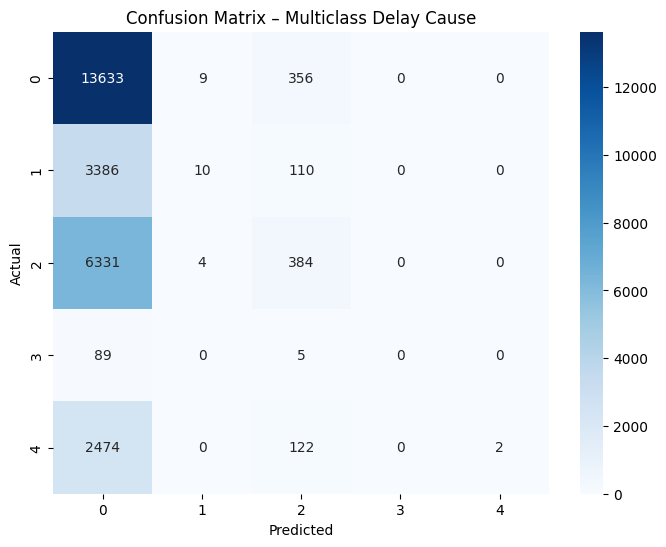

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train the model
dt_multi = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_multi.fit(X_train_multi, y_train_multi)

# Predictions
y_pred_multi = dt_multi.predict(X_test_multi)

# Evaluation
print("📊 Classification Report:")
print(classification_report(y_test_multi, y_pred_multi))

# Confusion Matrix
cm = confusion_matrix(y_test_multi, y_pred_multi)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Multiclass Delay Cause")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


📊 Classification Report – XGBoost:
              precision    recall  f1-score   support

           0       0.56      0.90      0.69     13998
           1       0.43      0.08      0.13      3506
           2       0.45      0.19      0.27      6719
           3       0.50      0.01      0.02        94
           4       0.43      0.12      0.19      2598

    accuracy                           0.54     26915
   macro avg       0.47      0.26      0.26     26915
weighted avg       0.50      0.54      0.46     26915



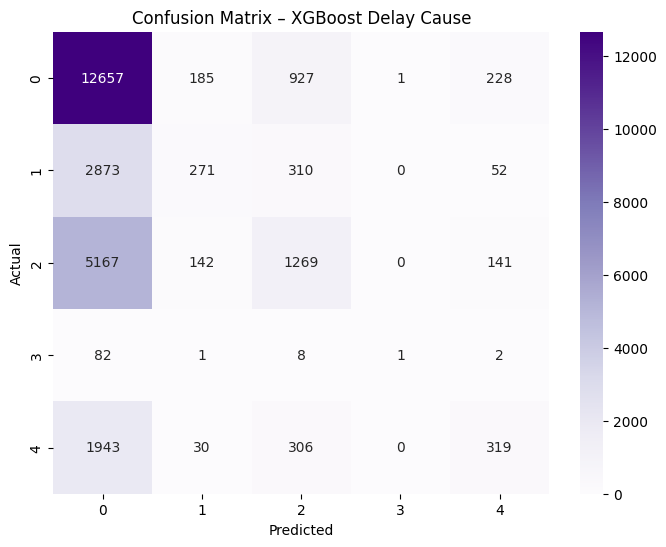

In [52]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train the XGBoost model
xgb_multi = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_multi.fit(X_train_multi, y_train_multi)

# Predict
y_pred_xgb = xgb_multi.predict(X_test_multi)

# Evaluate
print("📊 Classification Report – XGBoost:")
print(classification_report(y_test_multi, y_pred_xgb))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_multi, y_pred_xgb), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix – XGBoost Delay Cause")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [53]:
# 📌 1. Import libraries
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# 📌 2. (Optional) Load your dataset if needed
# df_multi = pd.read_csv("your_data.csv")

# 📌 3. Initialize encoders
airline_encoder = LabelEncoder()
origin_encoder = LabelEncoder()
dest_encoder = LabelEncoder()
label_encoder = LabelEncoder()

# 📌 4. Feature engineering & encoding
df_multi['DepHour'] = df_multi['CRSDepTime'] // 100  # Extract hour from HHMM
df_multi['Airline_encoded'] = airline_encoder.fit_transform(df_multi['IATA_Code_Marketing_Airline'])
df_multi['Origin_encoded'] = origin_encoder.fit_transform(df_multi['Origin'])
df_multi['Dest_encoded'] = dest_encoder.fit_transform(df_multi['Dest'])
df_multi['Target'] = label_encoder.fit_transform(df_multi['DelayCause'])

# 📌 5. Save encoders
with open("airline_encoder.pkl", "wb") as f:
    pickle.dump(airline_encoder, f)

with open("origin_encoder.pkl", "wb") as f:
    pickle.dump(origin_encoder, f)

with open("dest_encoder.pkl", "wb") as f:
    pickle.dump(dest_encoder, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# 📌 6. Define features and target
X = df_multi[['DepHour', 'DayOfWeek', 'Month', 'Airline_encoded', 'Origin_encoded', 'Dest_encoded']]
y = df_multi['Target']

# 📌 7. Train the XGBoost model
model = xgb.XGBClassifier()
model.fit(X, y)

# 📌 8. Save the trained model
with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model and encoders saved successfully!")


✅ Model and encoders saved successfully!


In [54]:
# Load model and encoders
with open("xgboost_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("airline_encoder.pkl", "rb") as f:
    airline_enc = pickle.load(f)

with open("origin_encoder.pkl", "rb") as f:
    origin_enc = pickle.load(f)

with open("dest_encoder.pkl", "rb") as f:
    dest_enc = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    label_enc = pickle.load(f)

# Example input (dict)
new_flight = {
    'IATA_Code_Marketing_Airline': 'DL',
    'Origin': 'ATL',
    'Dest': 'JFK',
    'CRSDepTime': 1430,
    'DayOfWeek': 3,
    'Month': 7
}

# Feature engineering
new_flight['DepHour'] = new_flight['CRSDepTime'] // 100
new_flight['Airline_encoded'] = airline_enc.transform([new_flight['IATA_Code_Marketing_Airline']])[0]
new_flight['Origin_encoded'] = origin_enc.transform([new_flight['Origin']])[0]
new_flight['Dest_encoded'] = dest_enc.transform([new_flight['Dest']])[0]

# Prepare for model
input_features = [[
    new_flight['DepHour'],
    new_flight['DayOfWeek'],
    new_flight['Month'],
    new_flight['Airline_encoded'],
    new_flight['Origin_encoded'],
    new_flight['Dest_encoded']
]]

# Predict
prediction = model.predict(input_features)
predicted_label = label_enc.inverse_transform(prediction)[0]

print("✈️ Predicted Cause of Delay:", predicted_label)


✈️ Predicted Cause of Delay: Carrier


## ✈️ Airline Clustering Based on Delay Patterns
We cluster airlines based on average delays due to various causes (Carrier, Weather, NAS, Security, Late Aircraft). This helps identify airlines with similar operational delay patterns.


In [55]:
df_multi.columns.tolist()


['IATA_Code_Marketing_Airline',
 'Origin',
 'Dest',
 'CRSDepTime',
 'DayOfWeek',
 'Month',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'SecurityDelay',
 'LateAircraftDelay',
 'DelayCause',
 'DepHour',
 'Airline_encoded',
 'Origin_encoded',
 'Dest_encoded',
 'Target']

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


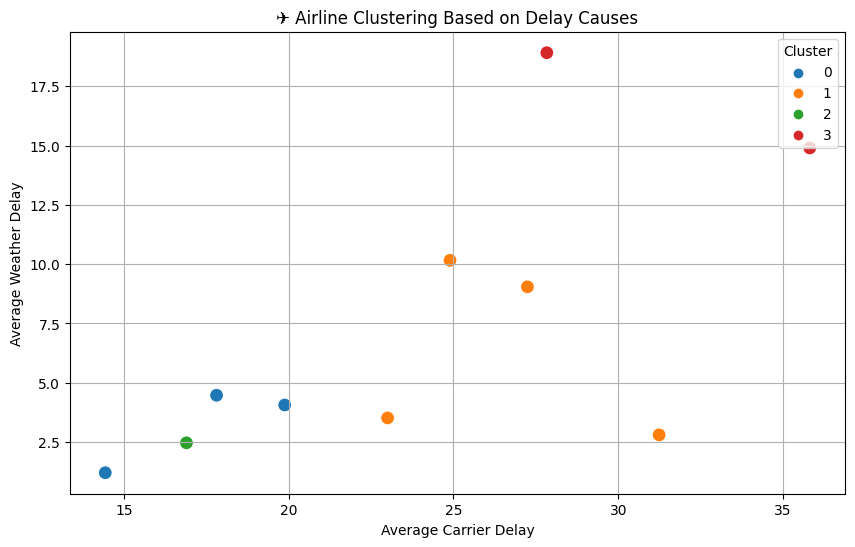

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Group by airline and calculate mean delay by cause
airline_stats = df_multi.groupby('IATA_Code_Marketing_Airline').agg({
    'CarrierDelay': 'mean',
    'WeatherDelay': 'mean',
    'NASDelay': 'mean',
    'SecurityDelay': 'mean',
    'LateAircraftDelay': 'mean'
}).fillna(0)

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(airline_stats)

# Run KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

# Assign cluster labels
airline_stats['Cluster'] = clusters

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=airline_stats, x='CarrierDelay', y='WeatherDelay', hue='Cluster', palette='tab10', s=100)
plt.title("✈️ Airline Clustering Based on Delay Causes")
plt.xlabel("Average Carrier Delay")
plt.ylabel("Average Weather Delay")
plt.grid(True)
plt.show()


## 🛫 Airport Clustering Based on Delay Causes
We perform clustering on origin airports to identify groups with similar delay profiles. Each airport is represented by the average delay due to different causes, helping us uncover operational patterns or systemic issues at specific hubs.


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128747 (\N{AIRPLANE DEPARTURE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


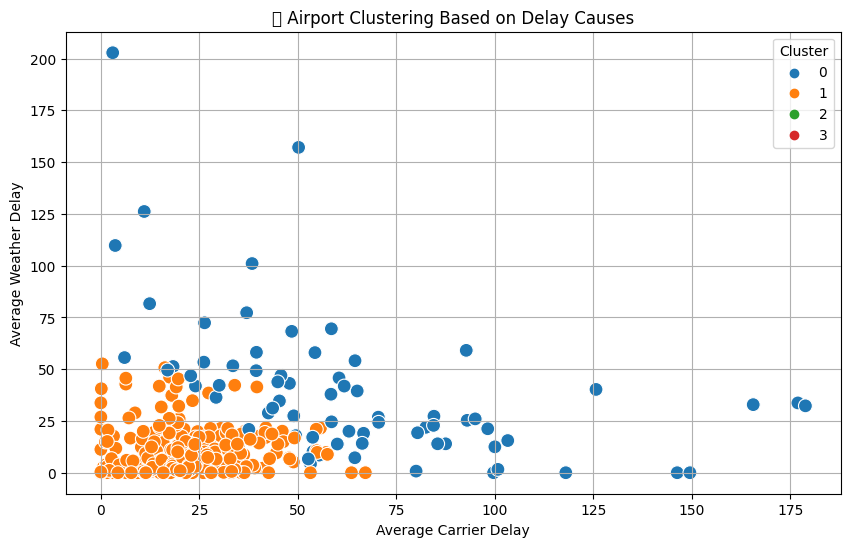

In [57]:
# Group by Origin (airport) and calculate average delay by cause
airport_stats = df_multi.groupby('Origin').agg({
    'CarrierDelay': 'mean',
    'WeatherDelay': 'mean',
    'NASDelay': 'mean',
    'SecurityDelay': 'mean',
    'LateAircraftDelay': 'mean'
}).fillna(0)

# Standardize features
scaled_airports = scaler.fit_transform(airport_stats)

# KMeans clustering (you can tune n_clusters as needed)
kmeans_airports = KMeans(n_clusters=4, random_state=42)
airport_clusters = kmeans_airports.fit_predict(scaled_airports)

# Assign cluster labels
airport_stats['Cluster'] = airport_clusters

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=airport_stats, x='CarrierDelay', y='WeatherDelay', hue='Cluster', palette='tab10', s=100)
plt.title("🛫 Airport Clustering Based on Delay Causes")
plt.xlabel("Average Carrier Delay")
plt.ylabel("Average Weather Delay")
plt.grid(True)
plt.show()


## ⏳ Time Series Forecasting: Predicting Future Flight Delays

In this section, we aim to forecast the average monthly arrival delay using time series techniques.  
This analysis can help airlines and airports to prepare for expected future delays and manage operations more efficiently.

We will:
1. Create a monthly time series of average arrival delays.
2. Visualize the trend.
3. Fit the Prophet model to forecast the next few months.


In [58]:
df[['FlightDate', 'ArrDelay']].dropna().head(10)


,FlightDate,ArrDelay
0,2024-01-14,45.0
1,2024-01-14,26.0
2,2024-01-14,86.0
3,2024-01-14,25.0
4,2024-01-14,18.0
5,2024-01-14,48.0
6,2024-01-14,11.0
8,2024-01-14,-12.0
9,2024-01-14,-35.0
11,2024-01-14,50.0


In [59]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'], errors='coerce')
print(df['FlightDate'].min(), "تا", df['FlightDate'].max())
print(df['FlightDate'].nunique(), "dates unique")


2024-01-01 00:00:00 تا 2024-01-31 00:00:00
31 dates unique


17:54:23 - cmdstanpy - INFO - Chain [1] start processing
17:54:24 - cmdstanpy - INFO - Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


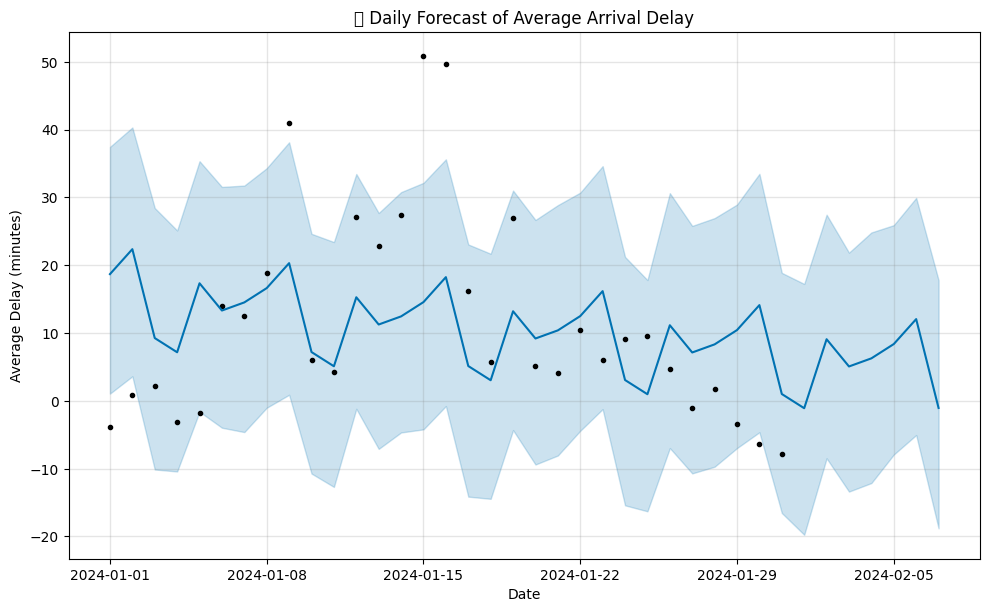

In [60]:
# 📌 Prepare daily average delay for time series forecasting with Prophet

# Import necessary libraries
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Prepare data
df_ts = df[['FlightDate', 'ArrDelay']].dropna().copy()
df_ts['FlightDate'] = pd.to_datetime(df_ts['FlightDate'])
daily_avg_delay = df_ts.groupby('FlightDate')['ArrDelay'].mean().reset_index()

# Step 2: Rename columns for Prophet
daily_avg_delay.columns = ['ds', 'y']

# Step 3: Fit Prophet model
model = Prophet()
model.fit(daily_avg_delay)

# Step 4: Create future dates (forecast 7 more days)
future = model.make_future_dataframe(periods=7, freq='D')

# Step 5: Forecast
forecast = model.predict(future)

# Step 6: Plot forecast
fig = model.plot(forecast)
plt.title('📈 Daily Forecast of Average Arrival Delay')
plt.xlabel('Date')
plt.ylabel('Average Delay (minutes)')
plt.show()


## 🧠 Model Explainability with SHAP

In this section, we will use SHAP (SHapley Additive exPlanations) to understand how each feature affects our model's predictions.

This is especially useful to:
- Interpret the decision-making process of complex models like XGBoost or LightGBM.
- Build trust and transparency in our predictions.
- Identify which features contribute the most to different delay causes.


In [61]:
# Create DepHour
df_multi['DepHour'] = df_multi['CRSDepTime'] // 100

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

airline_encoder = LabelEncoder()
df_multi['Airline_encoded'] = airline_encoder.fit_transform(df_multi['IATA_Code_Marketing_Airline'])

origin_encoder = LabelEncoder()
df_multi['Origin_encoded'] = origin_encoder.fit_transform(df_multi['Origin'])

dest_encoder = LabelEncoder()
df_multi['Dest_encoded'] = dest_encoder.fit_transform(df_multi['Dest'])

# Encode target
label_encoder = LabelEncoder()
df_multi['DelayCause'] = df_multi['DelayCause'].fillna("Unknown")  # اگه NaN داشته باشه
df_multi['DelayCause_encoded'] = label_encoder.fit_transform(df_multi['DelayCause'])


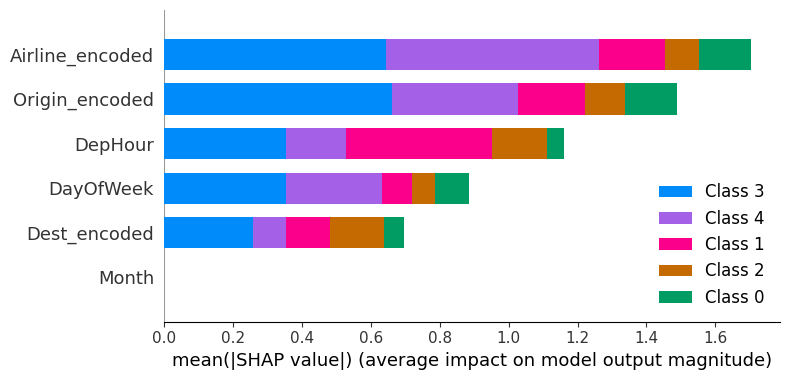

In [62]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd

# Ensure X is DataFrame
X = df_multi[['DepHour', 'DayOfWeek', 'Month', 'Airline_encoded', 'Origin_encoded', 'Dest_encoded']]
y = label_encoder.transform(df_multi['DelayCause'])

# Train XGBoost model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X, y)

# SHAP with TreeExplainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X, plot_type="bar")
